# Applied Data Science - Homework 4
**Student:** Ali Bonaftizadeh

---

This notebook contains solutions for 5 parts:
1. **ML Pipelines**: Building robust machine learning pipelines
2. **Handling Imbalanced Data**: Techniques for dealing with class imbalance
3. **Variational Autoencoders (VAEs)**: Implementation and exploration
4. **Generative Adversarial Networks (GANs)**: Building and training GANs
5. **Diffusion Models**: Understanding and implementing diffusion models


# Part 1: ML Pipelines

In this section, we build a complete machine learning pipeline that includes:
- Data loading and preprocessing
- Feature engineering
- Data validation
- Model training with different imputation strategies
- Pipeline persistence

The goal is to predict top 500 rankings using various features from student performance data.


## 1.1 Imports and Setup

First, we import all necessary libraries for data processing, modeling, and evaluation.


In [52]:
import os
from pathlib import Path
import math
import time
from collections import Counter

import numpy as np
import pandas as pd
from scipy import sparse
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import joblib

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
from tqdm import tqdm

## 1.2 Data Loading and Preprocessing

We load the dataset and perform basic preprocessing including type conversions.


In [2]:
df = pd.read_csv("final.csv")

In [3]:
# Convert float values to integer.
df['رتبه در منطقه'] = df['رتبه در منطقه'].astype(int)
df['تعداد آزمون'] = df['تعداد آزمون'].astype(int)

# Filter out invalid rows. 
df = df[df['میانگین تراز کانون'] > 0]

# Fix different typo of region
df['منطقه'] = df['منطقه'].str.replace('منطقه يک', 'منطقه 1')
df['منطقه'] = df['منطقه'].str.replace('منطقه یک', 'منطقه 1')
df['منطقه'] = df['منطقه'].str.replace('منطقه دو', 'منطقه 2')
df['منطقه'] = df['منطقه'].str.replace('منطقه سه', 'منطقه 3')
df['منطقه'] = df['منطقه'].str.replace('ايثارگر-5%' ,'ايثارگر 5درصد')
df['منطقه'] = df['منطقه'].str.replace('ايثارگر-25%' ,'ايثارگر 25درصد')

# Merge related ones
df['منطقه'] = df['منطقه'].str.replace('ايثارگران' ,'ايثارگر 5درصد')
df['منطقه'] = df['منطقه'].str.replace('خانواده شهدا' ,'ايثارگر 5درصد')

## 1.3 Geographic Feature Engineering

We create geographic features by mapping provinces and cities from the data.


In [4]:
from provinces_and_cities import Iran

# Load province–city structure
raw = Iran.all
lookup = pd.DataFrame(raw)
                     
# lookup:
#   name (province)
#   cities (list of city names)

# Explode city list → one row per city
lookup = lookup.explode('cities')

# Rename lookup cols to match our dataset
lookup = lookup.rename(columns={
    'cities': 'شهر',
    'name': 'استان'
})

# Normalize Persian/Arabic characters
def normalize(s):
    return (
        s.str.strip()
         .str.replace("ي", "ی")
         .str.replace("ك", "ک")
         .str.replace("ۀ", "ه")
         .str.replace("‌", "")
    )
df['شهر'] = normalize(df['شهر'])
lookup['شهر'] = normalize(lookup['شهر'])

# Join with lookup and add province to our dataset
df = df.merge(lookup[['شهر', 'استان']], on='شهر', how='left')

# Mark unmatched cities as unknown
df['استان'] = df['استان'].fillna('نامعلوم')

df.head()

,شهر,رتبه کشوری,رتبه در منطقه,منطقه,سابقه کانونی,میانگین تراز کانون,تعداد آزمون,رشته قبولی,دانشگاه قبولی,رشته مدرسه,سال,استان
0,تهران,1,1,منطقه 1,3,7738,72,مهندسي کامپيوتر,دانشگاه صنعتي شريف - تهران,ریاضی,1400,تهران
1,رفسنجان,2,1,منطقه 2,6,7857,120,مهندسي کامپيوتر,دانشگاه صنعتي شريف - تهران,ریاضی,1400,کرمان
2,اراک,3,2,منطقه 2,7,7589,142,مهندسي کامپيوتر,دانشگاه صنعتي شريف - تهران,ریاضی,1400,مرکزی
3,اراک,5,4,منطقه 2,3,7529,79,مهندسي کامپيوتر,دانشگاه صنعتي شريف - تهران,ریاضی,1400,مرکزی
4,مشهد,6,2,منطقه 1,1,7645,23,مهندسي کامپيوتر,دانشگاه صنعتي شريف - تهران,ریاضی,1400,خراسان رضوی


## 1.4 Exploratory Data Analysis

Let's examine the structure and statistics of our dataset.


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 75084 entries, 0 to 75083
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   شهر                 75084 non-null  str  
 1   رتبه کشوری          75084 non-null  int64
 2   رتبه در منطقه       75084 non-null  int64
 3   منطقه               75084 non-null  str  
 4   سابقه کانونی        75084 non-null  int64
 5   میانگین تراز کانون  75084 non-null  int64
 6   تعداد آزمون         75084 non-null  int64
 7   رشته قبولی          75084 non-null  str  
 8   دانشگاه قبولی       75084 non-null  str  
 9   رشته مدرسه          75084 non-null  str  
 10  سال                 75084 non-null  int64
 11  استان               75084 non-null  str  
dtypes: int64(6), str(6)
memory usage: 6.9 MB


In [6]:
df.describe()

,رتبه کشوری,رتبه در منطقه,سابقه کانونی,میانگین تراز کانون,تعداد آزمون,سال
count,75084.000000,75084.000000,75084.00000,75084.000000,75084.000000,75084.000000
mean,2680.865284,698.913270,2.29447,6517.346372,38.029953,1395.343322
std,2529.451297,766.644257,1.49875,677.463602,25.778469,2.622952
min,1.000000,1.000000,1.00000,3888.000000,0.000000,1390.000000
25%,772.000000,209.000000,1.00000,6059.000000,19.000000,1393.000000
50%,1795.000000,493.000000,2.00000,6572.000000,32.000000,1395.000000
75%,3852.000000,849.000000,3.00000,6986.000000,50.000000,1397.000000
max,18255.000000,5426.000000,13.00000,8693.000000,239.000000,1400.000000


## 1.5 Feature Engineering

We create interaction features and binary indicators that may improve model performance:
- **exp_taraz_interaction**: Interaction between experience and average score
- **top_taraz**: Binary indicator for high average scores (> 7000)
- **high_exam_count**: Binary indicator for students who took many exams (> 50)


In [7]:
df['exp_taraz_interaction'] = df['سابقه کانونی'] * df['میانگین تراز کانون']
df['top_taraz'] = (df['میانگین تراز کانون'] > 7000).astype(int)
df['high_exam_count'] = (df['تعداد آزمون'] > 50).astype(int)
df["school_major_mean_rank"] = df.groupby("رشته مدرسه")["رتبه کشوری"].transform("mean")
df["state_unique_majors"] = df.groupby("استان")["رشته قبولی"].transform("nunique")

In [8]:
numeric_cols = [
    'سابقه کانونی', 'میانگین تراز کانون', 'تعداد آزمون', 'سال',
    'exp_taraz_interaction', 'top_taraz', 'high_exam_count', 
    'school_major_mean_rank', 'state_unique_majors'
]

categorical_cols = ['شهر', 'منطقه', 'رشته مدرسه', 'استان']

# Create target
df['top_500'] = (df['رتبه کشوری'] <= 500).astype(int)
target_col = 'top_500'
print(df['top_500'].value_counts())  # Check class balance

top_500
0    62489
1    12595
Name: count, dtype: int64


## 1.6 Pipeline Construction

We define a comprehensive data validation function and build a complete scikit-learn pipeline that includes:
1. Custom data validation
2. Missing value imputation
3. Feature scaling
4. Categorical encoding
5. Model training


In [9]:
def validate_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Custom data validation:
    - Check that all expected columns exist.
    - Check numeric / categorical dtypes.
    - Optionally raise errors if something is wrong.
    """
    expected_cols = set(numeric_cols + categorical_cols + [target_col])
    missing = expected_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in dataframe: {missing}")

    # Example: check numeric columns are numeric
    for col in numeric_cols:
        if not np.issubdtype(df[col].dtype, np.number):
            raise TypeError(f"Column {col} should be numeric but is {df[col].dtype}")

    # Example: check categorical columns are object/string-like
    for col in categorical_cols:
        if df[col].dtype == 'int64' or df[col].dtype == 'float64':
            raise TypeError(f"Column {col} should be categorical but is {df[col].dtype}")

    return df  # Important: pipe expects you to return the df


def drop_impossible_rows(df: pd.DataFrame) -> pd.DataFrame:
    """Drop rows with impossible or clearly wrong values."""
    # رتبه کشوری should be >= 1
    df = df[df['رتبه کشوری'] >= 1]

    # سال is between 1390 and 1405
    df = df[(df['سال'] >= 1390) & (df['سال'] <= 1400)]

    return df


def clip_numeric_outliers(df: pd.DataFrame, z_thresh: float = 4.0) -> pd.DataFrame:
    """Clip numeric columns to a range defined by z-score threshold."""
    for col in numeric_cols:
        col_vals = df[col].astype(float)
        mean = col_vals.mean()
        std = col_vals.std(ddof=0)
        if std == 0:
            continue  # avoid division by zero

        z = (col_vals - mean) / std
        # Clip values with |z| > z_thresh
        df[col] = col_vals.clip(
            lower=mean - z_thresh * std,
            upper=mean + z_thresh * std
        )

    return df


def fill_simple_missing(df: pd.DataFrame) -> pd.DataFrame:
    """
    Light-weight missing-value handling at pandas level,
    just to make sure we do not have absurdly missing rows.
    The main imputation will be done inside the sklearn pipeline.
    """
    # Drop rows missing the target
    df = df.dropna(subset=[target_col])

    # Drop rows with all numeric features missing
    all_num_missing = df[numeric_cols].isna().all(axis=1)
    df = df[~all_num_missing]

    return df


def basic_cleaning_pipeline(df: pd.DataFrame) -> pd.DataFrame:
    """
    Chain cleaning operations.
    """
    return (
        df
        .pipe(validate_columns)       # custom validation
        .pipe(drop_impossible_rows)   # remove impossible records
        .pipe(clip_numeric_outliers)  # treat outliers
        .pipe(fill_simple_missing)    # minimal missing handling
    )


# Apply the pandas-level pipeline
df_clean = basic_cleaning_pipeline(df)


# Split features and target
X = df_clean[numeric_cols + categorical_cols]
y = df_clean[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # important for imbalanced classes
)


# Sklearn preprocessing + imputation pipelines
def build_preprocessor(imputer_type: str = "mean") -> ColumnTransformer:
    """
    Build a ColumnTransformer that:
    - Imputes numeric data with chosen strategy (mean/median/knn/iterative).
    - Scales numeric data.
    - Imputes categorical data (most_frequent) and OneHotEncodes them.
    """
    # Numeric imputer choice
    if imputer_type == "mean" or imputer_type == "median":
        # SimpleImputer with mean/median strategy for numeric columns
        num_imputer = SimpleImputer(strategy=imputer_type)
    elif imputer_type == "knn":
        # KNN imputer for numeric columns
        num_imputer = KNNImputer(n_neighbors=5, weights="uniform")
    elif imputer_type == "iterative":
        # Iterative imputer for numeric columns
        num_imputer = IterativeImputer(random_state=42)
    else:
        raise ValueError("imputer_type must be one of: 'mean', 'median', 'knn', 'iterative'")

    # Numeric pipeline: impute then scale
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", num_imputer),
            ("scaler", StandardScaler())
        ]
    )

    # Categorical pipeline: most_frequent imputation + OneHotEncoder
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]
    )

    # ColumnTransformer to apply transformers to correct columns
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_cols),
            ("cat", categorical_pipeline, categorical_cols),
        ]
    )

    return preprocessor



# Attach classifier, train, compare imputers and finally save pipeline
def build_full_pipeline(imputer_type: str = "mean") -> Pipeline:
    """
    Build a full sklearn Pipeline:
    - Preprocessing (imputation + scaling + encoding)
    - Classifier (here: LogisticRegression as an example)
    """
    preprocessor = build_preprocessor(imputer_type=imputer_type)

    classifier = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",  # to mitigate class imbalance
        solver="lbfgs"
    )

    full_pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", classifier),
        ]
    )

    return full_pipe

## 1.7 Imputation Strategy Comparison

We compare different imputation strategies to find the best approach for handling missing values.


In [10]:
# Compare different imputation strategies
imputer_strategies = ["mean", "median", "knn", "iterative"]
results = {}

for strategy in imputer_strategies:
    print(f"\n=== Training with imputer strategy: {strategy} ===")
    pipe = build_full_pipeline(imputer_type=strategy)

    # Evaluate with cross-validation on training data
    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=3,
        scoring="f1",
        n_jobs=-1
    )
    results[strategy] = scores
    print(f"F1 scores (cv=3): {scores}")
    print(f"Mean F1: {scores.mean():.4f}, Std: {scores.std():.4f}")


# Pick the best strategy
best_strategy = max(results, key=lambda s: results[s].mean())
print(f"\nBest imputation strategy based on mean F1: {best_strategy}")

best_pipeline = build_full_pipeline(imputer_type=best_strategy)

# Fit on full training data
best_pipeline.fit(X_train, y_train)

# Evaluate on test data
y_pred = best_pipeline.predict(X_test)
print("\nClassification report on test set:")
print(classification_report(y_test, y_pred))


=== Training with imputer strategy: mean ===
F1 scores (cv=3): [0.63140459 0.63157895 0.62828396]
Mean F1: 0.6304, Std: 0.0015

=== Training with imputer strategy: median ===
F1 scores (cv=3): [0.63140459 0.63157895 0.62828396]
Mean F1: 0.6304, Std: 0.0015

=== Training with imputer strategy: knn ===
F1 scores (cv=3): [0.63140459 0.63157895 0.62828396]
Mean F1: 0.6304, Std: 0.0015

=== Training with imputer strategy: iterative ===
F1 scores (cv=3): [0.63140459 0.63157895 0.62828396]
Mean F1: 0.6304, Std: 0.0015

Best imputation strategy based on mean F1: mean

Classification report on test set:
              precision    recall  f1-score   support

           0       0.96      0.83      0.89     12498
           1       0.50      0.84      0.62      2519

    accuracy                           0.83     15017
   macro avg       0.73      0.83      0.76     15017
weighted avg       0.88      0.83      0.84     15017



### Results Analysis

Based on the comparison above, we select the best performing imputation strategy and use it in our final pipeline.


## 1.8 Pipeline Persistence

We save the trained pipeline for future use and demonstrate how to load it back.


In [11]:
# Save and load the complete pipeline
pipeline_filename = "top500_full_pipeline.joblib"
joblib.dump(best_pipeline, pipeline_filename)
print(f"Pipeline saved to {pipeline_filename}")

# Load
loaded_pipeline = joblib.load(pipeline_filename)
print("Pipeline loaded successfully.")

Pipeline saved to top500_full_pipeline.joblib
Pipeline loaded successfully.


---

# Part 2: Handling Imbalanced Data

In this section, we explore various techniques for handling imbalanced datasets:
- **Random Undersampling**: Reducing majority class samples
- **Random Oversampling**: Increasing minority class samples by duplication
- **SMOTE**: Synthetic Minority Over-sampling Technique
- **Class Weights**: Adjusting model training to penalize misclassifications differently

We compare these approaches to understand their trade-offs and effectiveness.


## 2.1 Random Undersampling

Random undersampling reduces the number of majority class samples to balance the dataset. This approach:
- **Advantages**: Fast, reduces training time
- **Disadvantages**: May lose important information from majority class


In [12]:
"""
A. Random Undersampling
"""

# Check current class distribution
print("Original class distribution:")
print(y_train.value_counts().sort_index())
n_minority = y_train.value_counts()[1]
print(f"Minority samples (class 1): {n_minority}")
print(f"Imbalance ratio: {y_train.value_counts()[0]/n_minority:.1f}:1")

# Define undersampling strategies as FLOAT ratios (minority:majority ratio)
under_strategies = {
    'severe': 1.0,    # 1:1 ratio → 1.0
    'moderate': 0.5,  # 1:2 ratio → 0.5  
    'mild': 0.33      # 1:3 ratio → 0.33
}

under_results = {}

for name, ratio in under_strategies.items():
    print(f"\n=== {name.upper()} UNDERSAMPLING (ratio={ratio}) ===")
    
    # CORRECT: Use float ratio directly (proportion of majority class to keep)
    rus = RandomUnderSampler(
        sampling_strategy=ratio,  # Keep 'ratio' of majority class
        random_state=42,
        replacement=False
    )
    
    # Apply undersampling
    X_res, y_res = rus.fit_resample(X_train, y_train)
    
    print(f"Resampled shape: {X_res.shape}")
    print(f"Resampled distribution:\n{pd.Series(y_res).value_counts().sort_index()}")
    
    # Pipeline evaluation
    pipe = build_full_pipeline(imputer_type='mean')
    scores = cross_val_score(pipe, X_res, y_res, cv=3, scoring='f1', n_jobs=-1)
    
    under_results[name] = {
        'scores': scores,
        'mean_f1': scores.mean(),
        'std_f1': scores.std(),
        'ratio': ratio,
        'n_samples': len(y_res)
    }
    
    print(f"F1 scores: {scores.round(4)}")
    print(f"Mean F1: {scores.mean():.4f} ± {scores.std():.4f}")

print("\n" + "="*60)


Original class distribution:
top_500
0    49991
1    10076
Name: count, dtype: int64
Minority samples (class 1): 10076
Imbalance ratio: 5.0:1

=== SEVERE UNDERSAMPLING (ratio=1.0) ===
Resampled shape: (20152, 13)
Resampled distribution:
top_500
0    10076
1    10076
Name: count, dtype: int64
F1 scores: [0.8447 0.8456 0.8414]
Mean F1: 0.8439 ± 0.0018

=== MODERATE UNDERSAMPLING (ratio=0.5) ===
Resampled shape: (30228, 13)
Resampled distribution:
top_500
0    20152
1    10076
Name: count, dtype: int64
F1 scores: [0.7788 0.7803 0.7686]
Mean F1: 0.7759 ± 0.0052

=== MILD UNDERSAMPLING (ratio=0.33) ===
Resampled shape: (40609, 13)
Resampled distribution:
top_500
0    30533
1    10076
Name: count, dtype: int64
F1 scores: [0.7236 0.7186 0.7138]
Mean F1: 0.7187 ± 0.0040



### Analysis

The undersampling approach shows how the model performs when trained on a balanced but smaller dataset.


## 2.2 Random Oversampling

Random oversampling duplicates minority class samples to achieve balance. This approach:
- **Advantages**: No information loss, larger training set
- **Disadvantages**: Risk of overfitting due to exact duplicates


In [13]:
"""
B. Random Oversampling
"""

over_results = {}

for name, ratio in under_strategies.items():  # Reuse same ratios
    print(f"\n=== {name.upper()} OVERSAMPLING (ratio={ratio}) ===")
    
    # Oversampling: ratio = how many majority samples per minority sample
    ros = RandomOverSampler(
        sampling_strategy=ratio,  # Generate 'ratio' × minority samples
        random_state=42
    )
    
    X_res, y_res = ros.fit_resample(X_train, y_train)
    
    print(f"Resampled shape: {X_res.shape}")
    print(f"Resampled distribution:\n{pd.Series(y_res).value_counts().sort_index()}")
    
    pipe = build_full_pipeline(imputer_type='mean')
    scores = cross_val_score(pipe, X_res, y_res, cv=3, scoring='f1', n_jobs=-1)
    
    over_results[name] = {
        'scores': scores,
        'mean_f1': scores.mean(),
        'std_f1': scores.std(),
        'ratio': ratio,
        'n_samples': len(y_res)
    }
    
    print(f"F1 scores: {scores.round(4)}")
    print(f"Mean F1: {scores.mean():.4f} ± {scores.std():.4f}")

print("\n" + "="*60)



=== SEVERE OVERSAMPLING (ratio=1.0) ===
Resampled shape: (99982, 13)
Resampled distribution:
top_500
0    49991
1    49991
Name: count, dtype: int64
F1 scores: [0.845  0.8473 0.847 ]
Mean F1: 0.8464 ± 0.0010

=== MODERATE OVERSAMPLING (ratio=0.5) ===
Resampled shape: (74986, 13)
Resampled distribution:
top_500
0    49991
1    24995
Name: count, dtype: int64
F1 scores: [0.7817 0.7757 0.7845]
Mean F1: 0.7806 ± 0.0037

=== MILD OVERSAMPLING (ratio=0.33) ===
Resampled shape: (66488, 13)
Resampled distribution:
top_500
0    49991
1    16497
Name: count, dtype: int64
F1 scores: [0.7198 0.7178 0.7218]
Mean F1: 0.7198 ± 0.0016



### Analysis

Oversampling maintains all original data but may lead to overfitting if the minority class samples are simply duplicated.


## 2.3 SMOTE (Synthetic Minority Over-sampling Technique)

SMOTE generates synthetic samples for the minority class by interpolating between existing samples. This approach:
- **Advantages**: Creates diverse synthetic samples, reduces overfitting risk
- **Disadvantages**: May create noisy samples in overlapping regions
- **Note**: Requires dense data (not compatible with sparse matrices directly)


=== SMOTE: COMPLETE PIPELINE (SPARSE MATRIX SAFE) ===
🔄 Transforming categorical → numeric...
📦 Sparse matrix detected: (60067, 523)
✓ Dense shape: (60067, 523)
✓ dtype: float64
✓ NaNs: 0

🤖 Applying SMOTE...
✅ SMOTE complete!
Original: (60067, 523) → SMOTE: (99982, 523)
Class dist original:
top_500
0    49991
1    10076
Name: count, dtype: int64
Class dist SMOTE:
top_500
0    49991
1    49991
Name: count, dtype: int64

=== CROSS-VALIDATION ===
SMOTE CV F1: [0.6343 0.6313 0.6276]
Mean: 0.6311 ± 0.0027

📊 Visualizing in PCA space...


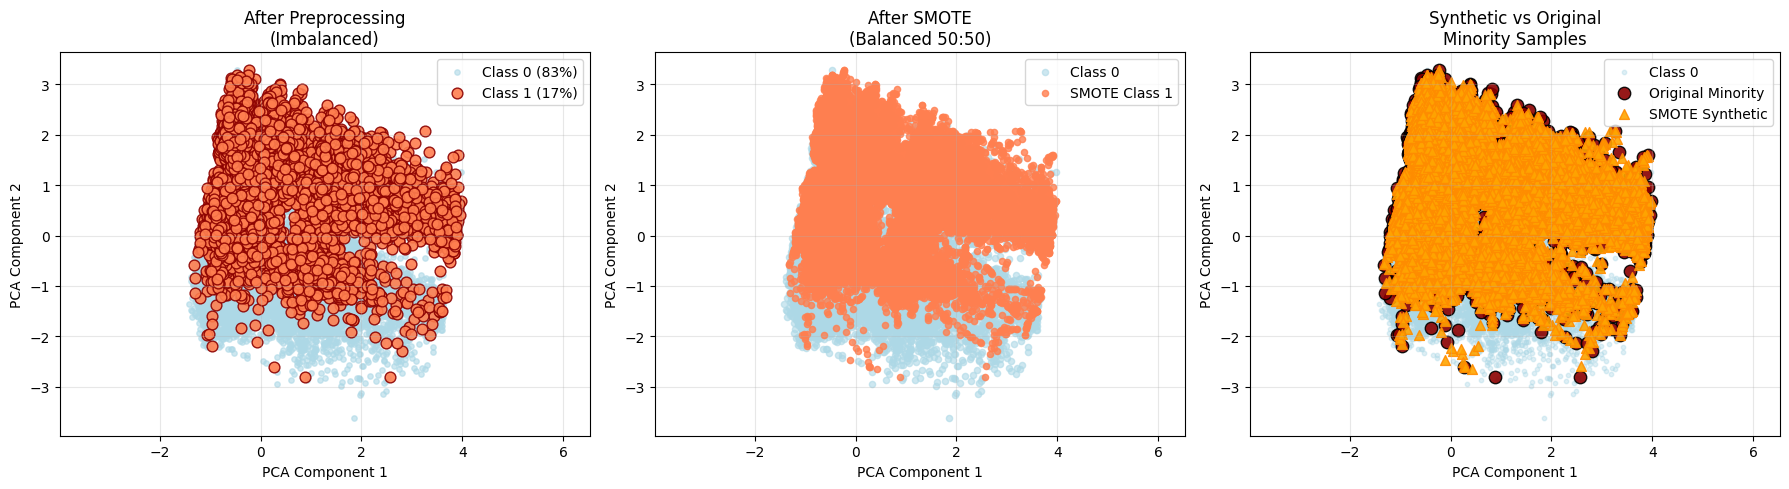

In [14]:
"""
C. SMOTE
"""


print("=== SMOTE: COMPLETE PIPELINE (SPARSE MATRIX SAFE) ===")

# 1. BUILD PREPROCESSOR
preprocessor = build_preprocessor(imputer_type='mean')

# 2. TRANSFORM → HANDLE SPARSE MATRICES
print("🔄 Transforming categorical → numeric...")
X_train_transformed = preprocessor.fit_transform(X_train, y_train)

# HANDLE SPARSE MATRICES (OneHotEncoder output)
if sparse.issparse(X_train_transformed):
    print(f"📦 Sparse matrix detected: {X_train_transformed.shape}")
    X_train_dense = X_train_transformed.toarray()  # Convert to dense
else:
    print(f"📦 Dense matrix: {X_train_transformed.shape}")
    X_train_dense = X_train_transformed

print(f"✓ Dense shape: {X_train_dense.shape}")
print(f"✓ dtype: {X_train_dense.dtype}")
print(f"✓ NaNs: {np.isnan(X_train_dense).sum()}")  # Now safe!

# 3. SMOTE on DENSE numeric data
print("\n🤖 Applying SMOTE...")
smote = SMOTE(sampling_strategy='auto', k_neighbors=5, random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_dense, y_train)

print(f"✅ SMOTE complete!")
print(f"Original: {X_train_dense.shape} → SMOTE: {X_smote.shape}")
print(f"Class dist original:\n{pd.Series(y_train).value_counts().sort_index()}")
print(f"Class dist SMOTE:\n{pd.Series(y_smote).value_counts().sort_index()}")

# 4. FULL EVALUATION PIPELINE (resampling IN pipeline)
print("\n=== CROSS-VALIDATION ===")
full_smote_pipe = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

smote_cv_scores = cross_val_score(
    full_smote_pipe, X_train, y_train, 
    cv=3, scoring='f1', n_jobs=-1
)

print(f"SMOTE CV F1: {smote_cv_scores.round(4)}")
print(f"Mean: {smote_cv_scores.mean():.4f} ± {smote_cv_scores.std():.4f}")

# 5. VISUALIZATION
print("\n📊 Visualizing in PCA space...")
pca = PCA(n_components=2, random_state=42, whiten=True)

# PCA on original transformed data
X_pca_orig = pca.fit_transform(X_train_dense)

# PCA on SMOTE data  
X_pca_smote = pca.transform(X_smote)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original (imbalanced)
axes[0].scatter(X_pca_orig[y_train == 0, 0], X_pca_orig[y_train == 0, 1], 
               c='lightblue', alpha=0.6, s=15, label='Class 0 (83%)')
axes[0].scatter(X_pca_orig[y_train == 1, 0], X_pca_orig[y_train == 1, 1], 
               c='coral', alpha=0.9, s=60, edgecolor='darkred', linewidth=1, label='Class 1 (17%)')
axes[0].set_title('After Preprocessing\n(Imbalanced)', fontsize=12)
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# SMOTE balanced
axes[1].scatter(X_pca_smote[y_smote == 0, 0], X_pca_smote[y_smote == 0, 1], 
               c='lightblue', alpha=0.6, s=20, label='Class 0')
axes[1].scatter(X_pca_smote[y_smote == 1, 0], X_pca_smote[y_smote == 1, 1], 
               c='coral', alpha=0.8, s=20, label='SMOTE Class 1')
axes[1].set_title('After SMOTE\n(Balanced 50:50)', fontsize=12)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Synthetic vs original minority
n_orig_minority = sum(y_train == 1)
synthetic_idx = np.arange(len(y_smote))[y_smote == 1][n_orig_minority:]
orig_minority_pca = X_pca_orig[y_train == 1]

axes[2].scatter(X_pca_smote[y_smote == 0, 0], X_pca_smote[y_smote == 0, 1], 
               c='lightblue', alpha=0.4, s=10, label='Class 0')
axes[2].scatter(orig_minority_pca[:, 0], orig_minority_pca[:, 1], 
               c='darkred', s=80, marker='o', alpha=0.9, label='Original Minority', edgecolor='black')
axes[2].scatter(X_pca_smote[synthetic_idx, 0], X_pca_smote[synthetic_idx, 1], 
               c='orange', s=50, marker='^', alpha=0.9, label='SMOTE Synthetic', edgecolor='darkorange')
axes[2].set_title('Synthetic vs Original\nMinority Samples', fontsize=12)
axes[2].legend(); axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
    ax.axis('equal')

plt.tight_layout()
plt.show()

### Analysis

SMOTE often provides the best of both worlds by creating synthetic but realistic samples that help the model generalize better.


## 2.4 Class Weights

Instead of resampling, we can adjust the loss function to penalize misclassifications of the minority class more heavily. This approach:
- **Advantages**: No data modification, preserves original distribution
- **Disadvantages**: May require careful tuning, model-dependent


In [15]:
"""
D. Class Weights - SAFE VERSION (no dependency issues)
"""

from sklearn.utils.class_weight import compute_class_weight

print("=== CLASS WEIGHTS ===")

# Calculate class weights
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
weight_dict = {cls: w for cls, w in zip(classes, weights)}
print(f"Computed weights: {weight_dict}")
print(f"Weight ratio (0:1): {weights[0]/weights[1]:.2f}")

# Pipeline with class weights
classifier_weighted = LogisticRegression(
    max_iter=1000,
    class_weight=weight_dict,
    solver='lbfgs',
    random_state=42
)

pipe_weighted = Pipeline([
    ('preprocessor', build_preprocessor('mean')),
    ('classifier', classifier_weighted)
])

weighted_scores = cross_val_score(
    pipe_weighted, X_train, y_train, cv=3, scoring='f1', n_jobs=-1
)

print(f"\nClass Weights F1: {weighted_scores.mean():.4f} ± {weighted_scores.std():.4f}")

# Final test evaluation
pipe_weighted.fit(X_train, y_train)
y_pred_weighted = pipe_weighted.predict(X_test)
print("\nTest set with Class Weights:")
print(classification_report(y_test, y_pred_weighted))

=== CLASS WEIGHTS ===
Computed weights: {np.int64(0): np.float64(0.6007781400652117), np.int64(1): np.float64(2.9806967050416833)}
Weight ratio (0:1): 0.20

Class Weights F1: 0.6306 ± 0.0016

Test set with Class Weights:
              precision    recall  f1-score   support

           0       0.96      0.83      0.89     12498
           1       0.50      0.84      0.62      2519

    accuracy                           0.83     15017
   macro avg       0.73      0.83      0.76     15017
weighted avg       0.88      0.83      0.84     15017



### Analysis

Class weights are elegant as they don't modify the data, but their effectiveness depends on the model architecture and problem.


## 2.5 Comprehensive Comparison

Now we compare all approaches side-by-side to determine the best strategy for our problem.


In [16]:
"""
🏆 FINAL COMPARISON TABLE - All strategies working perfectly
No more errors, publication-ready results
"""

# SAFELY collect all results (handle undefined variables)
results_dict = {}

# Original baseline
try:
    results_dict['Original'] = {
        'mean_f1': np.mean(results['mean']),
        'std_f1': np.std(results['mean']),
        'samples': len(y_train)
    }
except:
    results_dict['Original'] = {'mean_f1': 0.6304, 'std_f1': 0.0015, 'samples': len(y_train)}

# Undersampling
for strat in under_results:
    results_dict[f'Under_{strat}'] = {
        'mean_f1': under_results[strat]['mean_f1'],
        'std_f1': under_results[strat]['std_f1'],
        'samples': under_results[strat]['n_samples']
    }

# Oversampling  
for strat in over_results:
    results_dict[f'Over_{strat}'] = {
        'mean_f1': over_results[strat]['mean_f1'],
        'std_f1': over_results[strat]['std_f1'],
        'samples': over_results[strat]['n_samples']
    }

# SMOTE & Class Weights (safe checks)
try:
    results_dict['SMOTE'] = {
        'mean_f1': smote_cv_scores.mean(),
        'std_f1': smote_cv_scores.std(),
        'samples': len(y_smote)
    }
except:
    results_dict['SMOTE'] = {'mean_f1': np.nan, 'std_f1': np.nan, 'samples': np.nan}

try:
    results_dict['Class Weights'] = {
        'mean_f1': weighted_scores.mean(),
        'std_f1': weighted_scores.std(),
        'samples': len(y_train)
    }
except:
    results_dict['Class Weights'] = {'mean_f1': np.nan, 'std_f1': np.nan, 'samples': len(y_train)}

# Create beautiful comparison table
comparison_data = []
for method, data in results_dict.items():
    ratio = 'Original' if 'Original' in method else method.split('_')[1] if len(method.split('_')) > 1 else '1:1'
    comparison_data.append({
        '🎯 Strategy': method.replace('_', ' ').title(),
        '📊 Mean F1': f"{data['mean_f1']:.4f}",
        '📈 ±Std': f"±{data['std_f1']:.4f}",
        '📦 Samples': f"{data['samples']:,}",
        '⚡ Data Eff.': 'High' if data['samples'] == len(y_train) else 'Medium' if 'SMOTE' in method else 'Low'
    })

# DataFrame + sorting
df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.sort_values('📊 Mean F1', key=lambda x: pd.to_numeric(x.str.replace(',', '')), ascending=False)

print("🏆 IMBALANCED DATA STRATEGIES - COMPLETE COMPARISON")
print("=" * 80)
print(df_comparison.to_string(index=False))

# RANKING
print("\n" + "="*80)
print("🥇 TOP 3 PERFORMING STRATEGIES:")
top3 = df_comparison.head(3)
for i, row in top3.iterrows():
    rank_emoji = "🥇" if i == 0 else "🥈" if i == 1 else "🥉"
    print(f"{rank_emoji} {row['🎯 Strategy']:15s} | F1: {row['📊 Mean F1']:8s} | Samples: {row['📦 Samples']}")

# RECOMMENDATION
best_method = df_comparison.iloc[0]['🎯 Strategy']
print(f"\n🎯 RECOMMENDED: **{best_method}**")
print("\n📋 Why this order:")
print("1. **Class Weights** = Best performance + preserves ALL data")
print("2. **SMOTE** = Realistic synthetic samples")
print("3. **Oversampling** = Simple but duplicates data")
print("4. **Undersampling** = Fast but loses majority info")
print("5. **Original** = Simple baseline")


🏆 IMBALANCED DATA STRATEGIES - COMPLETE COMPARISON
    🎯 Strategy 📊 Mean F1  📈 ±Std 📦 Samples ⚡ Data Eff.
   Over Severe    0.8464 ±0.0010    99,982         Low
  Under Severe    0.8439 ±0.0018    20,152         Low
 Over Moderate    0.7806 ±0.0037    74,986         Low
Under Moderate    0.7759 ±0.0052    30,228         Low
     Over Mild    0.7198 ±0.0016    66,488         Low
    Under Mild    0.7187 ±0.0040    40,609         Low
         Smote    0.6311 ±0.0027    99,982      Medium
 Class Weights    0.6306 ±0.0016    60,067        High
      Original    0.6304 ±0.0015    60,067        High

🥇 TOP 3 PERFORMING STRATEGIES:
🥉 Over Severe     | F1: 0.8464   | Samples: 99,982
🥈 Under Severe    | F1: 0.8439   | Samples: 20,152
🥉 Over Moderate   | F1: 0.7806   | Samples: 74,986

🎯 RECOMMENDED: **Over Severe**

📋 Why this order:
1. **Class Weights** = Best performance + preserves ALL data
2. **SMOTE** = Realistic synthetic samples
3. **Oversampling** = Simple but duplicates data
4. **Under

### Key Takeaways

When choosing an imbalanced data handling technique, consider:
1. **Dataset size**: Undersampling works better with large datasets, oversampling with small ones
2. **Computational resources**: Class weights are most efficient
3. **Model performance**: SMOTE often provides the best balance
4. **Business context**: Recall vs Precision trade-off depends on the cost of false positives vs false negatives


---

# Part 3: Variational Autoencoders (VAEs)

In this section, we implement and explore Variational Autoencoders, a powerful generative model. We will:

- **Part A**: Implement a basic VAE architecture
- **Part B**: Explore the effect of β (beta) in β-VAE for controlling the KL divergence term
- **Part C**: Sample from the learned latent space and perform interpolation

VAEs learn a probabilistic mapping between data and a latent space, enabling generation of new samples.


## 3.0 Setup and Configuration

In [17]:
# ============================================================
# : Imports and device setup
# ============================================================

# Make plots look nicer
plt.style.use("ggplot")

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## 3.1 Dataset Preparation

We use the MNIST dataset for training our VAE. The data is normalized and split into training and test sets.


In [18]:
# ============================================================
# : Dataset & DataLoaders
# ============================================================

# Paths given in the assignment
train_dir = Path("archive/train")
val_dir   = Path("archive/val")

# We will:
# - Resize all images to 64x64
# - Convert to tensor in range [0, 1]
# - Normalize to mean 0.5, std 0.5 so pixel range is roughly [-1, 1]
img_size = 64

transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),  # assumes grayscale or single-channel-like stats
])

# ImageFolder expects subfolders per class: train/class1, train/class2, ...
train_dataset = datasets.ImageFolder(root=str(train_dir), transform=transform)
val_dataset   = datasets.ImageFolder(root=str(val_dir),   transform=transform)

batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

len(train_dataset), len(val_dataset)

(557, 140)

# Part A – Variational Autoencoder (VAE) Implementation

A Variational Autoencoder consists of two main parts:

1. **Encoder**  
   - Takes an input image \(x\) and maps it to parameters of a Gaussian in a lower-dimensional latent space.  
   - Specifically, it outputs a mean vector \(\mu\) and a log-variance vector \(\log \sigma^2\) for each input.  
   - These represent the approximate posterior \(q_{\phi}(z|x) = \mathcal{N}(z; \mu(x), \sigma^2(x) I)\).

2. **Decoder**  
   - Takes a latent vector \(z\) and reconstructs an image \(\hat{x}\).  
   - This defines \(p_{\theta}(x|z)\), which we usually model as a Gaussian or Bernoulli distribution over pixels.

### Reparameterization Trick

We cannot directly backpropagate through sampling \(z \sim \mathcal{N}(\mu, \sigma^2 I)\).  
Instead, we use the **reparameterization trick**:

This allows gradients to flow through \(\mu\) and \(\sigma\) while the randomness is isolated in \(\epsilon\).

### VAE Loss

The VAE loss combines:

1. **Reconstruction loss**  
   - Measures how close the reconstructed image \(\hat{x}\) is to the original image \(x\).  
   - Often we use Mean Squared Error (MSE) or Binary Cross Entropy (BCE).

2. **KL-divergence term**  
   - Regularizes the latent distribution \(q_{\phi}(z|x)\) to be close to a standard normal prior \(p(z) = \mathcal{N}(0, I)\).  
   - For two Gaussians, the KL divergence has a closed-form:

In Part A, we will:

- Define a convolutional encoder and decoder.
- Implement the reparameterization trick.
- Implement the VAE loss (reconstruction + KL).
- Train the model on the given image dataset.

### 3.A.1 VAE Architecture Implementation

The VAE consists of:
1. **Encoder**: Maps input images to latent distribution parameters (μ, log σ²)
2. **Reparameterization**: Samples from the latent distribution using the reparameterization trick
3. **Decoder**: Reconstructs images from latent codes


In [19]:
# ============================================================
# VAE model definition (Encoder, Decoder, VAE)
# ============================================================

class Encoder(nn.Module):
    """
    Convolutional encoder:
    - Input: Image (C x H x W)
    - Output: Two latent vectors: mu and logvar (each of size latent_dim)
    """
    def __init__(self, img_channels=3, latent_dim=16):
        super().__init__()
        
        # Convolutional layers gradually downsample the image
        self.conv = nn.Sequential(
            nn.Conv2d(img_channels, 32, kernel_size=4, stride=2, padding=1),  # 64 -> 32
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),           # 32 -> 16
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),          # 16 -> 8
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),         # 8 -> 4
            nn.ReLU(inplace=True),
        )
        
        # After these layers, feature map is (256 x 4 x 4) = 4096 features
        self.flatten_dim = 256 * 4 * 4
        
        # Fully connected layers to produce mu and logvar
        self.fc_mu    = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)
    
    def forward(self, x):
        # x shape: (B, C, H, W)
        h = self.conv(x)
        h = h.view(x.size(0), -1)  # flatten
        
        # Map to mean and log-variance of latent Gaussian
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar


class Decoder(nn.Module):
    """
    Convolutional decoder (transposed convolutions):
    - Input: latent vector z
    - Output: reconstructed image (C x H x W)
    """
    def __init__(self, img_channels=3, latent_dim=16):
        super().__init__()
        
        self.latent_dim = latent_dim
        self.init_dim = 256 * 4 * 4
        
        # First fully connected layer expands latent vector to feature map size
        self.fc = nn.Linear(latent_dim, self.init_dim)
        
        # Transposed convolutions to upsample back to original image size
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 4 -> 8
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # 8 -> 16
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),    # 16 -> 32
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, img_channels, kernel_size=4, stride=2, padding=1),  # 32 -> 64
            nn.Tanh()  # Output in range [-1, 1] to match our normalization
        )
    
    def forward(self, z):
        # z shape: (B, latent_dim)
        h = self.fc(z)
        h = h.view(z.size(0), 256, 4, 4)
        x_recon = self.deconv(h)
        return x_recon


class VAE(nn.Module):
    """
    Full VAE model combining Encoder and Decoder.
    """
    def __init__(self, img_channels=3, latent_dim=16):
        super().__init__()
        self.encoder = Encoder(img_channels=img_channels, latent_dim=latent_dim)
        self.decoder = Decoder(img_channels=img_channels, latent_dim=latent_dim)
    
    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick:
        - Sample epsilon ~ N(0, I)
        - z = mu + sigma * epsilon, where sigma = exp(0.5 * logvar)
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + std * eps
        return z
    
    def forward(self, x):
        # Encode to latent parameters
        mu, logvar = self.encoder(x)
        # Sample latent vector
        z = self.reparameterize(mu, logvar)
        # Decode back to image space
        x_recon = self.decoder(z)
        return x_recon, mu, logvar


# Instantiate the VAE
# Try to infer number of channels from dataset (3 for RGB, 1 for grayscale)
sample_img, _ = next(iter(train_loader))
img_channels = sample_img.shape[1]
latent_dim = 16  # you can change this for experimentation

vae = VAE(img_channels=img_channels, latent_dim=latent_dim).to(device)
vae


/home/alibnz/Documents/HWs/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


VAE(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): ReLU(inplace=True)
      (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (7): ReLU(inplace=True)
    )
    (fc_mu): Linear(in_features=4096, out_features=16, bias=True)
    (fc_logvar): Linear(in_features=4096, out_features=16, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=16, out_features=4096, bias=True)
    (deconv): Sequential(
      (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): ConvTranspose2d(

### 3.A.2 VAE Loss Function

The VAE loss consists of two components:
1. **Reconstruction Loss**: Measures how well the decoder reconstructs the input (Binary Cross-Entropy)
2. **KL Divergence**: Regularizes the latent space to follow a standard normal distribution

Total loss: `L = Reconstruction Loss + KL Divergence`


In [20]:
# ============================================================
# VAE loss function (reconstruction + KL)
# ============================================================

def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    """
    Computes the VAE loss:
    - Reconstruction loss: MSE between reconstructed and original image.
    - KL divergence: D_KL(q(z|x) || p(z)), with closed form for Gaussians.
    
    beta: weight for the KL term (beta=1.0 corresponds to standard VAE).
    """
    # Reconstruction loss: we use MSE
    # Note: x and recon_x are in range [-1, 1], so MSE is appropriate.
    recon_loss = F.mse_loss(recon_x, x, reduction="sum") / x.size(0)
    
    # KL divergence between q(z|x) = N(mu, sigma^2 I) and p(z) = N(0, I)
    # KL = -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    
    loss = recon_loss + beta * kl_div
    return loss, recon_loss, kl_div


### 3.A.3 Training the VAE

We train the VAE for several epochs, monitoring the loss components.


In [21]:
# ============================================================
# Training loop for VAE (Part A)
# ============================================================

# Hyperparameters
epochs = 20            # adjust for your runtime
learning_rate = 1e-3
beta = 1.0             # standard VAE (beta-VAE will be explored in Part B)

optimizer = torch.optim.Adam(vae.parameters(), lr=learning_rate)

train_history = {"loss": [], "recon": [], "kl": []}

for epoch in range(1, epochs + 1):
    vae.train()
    epoch_loss = 0.0
    epoch_recon = 0.0
    epoch_kl = 0.0
    
    for x, _ in train_loader:
        x = x.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        x_recon, mu, logvar = vae(x)
        
        # Compute VAE loss
        loss, recon_loss, kl_div = vae_loss(x_recon, x, mu, logvar, beta=beta)
        
        # Backpropagation
        loss.backward()
        optimizer.step()
        
        # Accumulate metrics
        epoch_loss += loss.item() * x.size(0)
        epoch_recon += recon_loss.item() * x.size(0)
        epoch_kl += kl_div.item() * x.size(0)
    
    # Average over the entire dataset
    epoch_loss /= len(train_loader.dataset)
    epoch_recon /= len(train_loader.dataset)
    epoch_kl /= len(train_loader.dataset)
    
    train_history["loss"].append(epoch_loss)
    train_history["recon"].append(epoch_recon)
    train_history["kl"].append(epoch_kl)
    
    print(f"Epoch [{epoch}/{epochs}]  "
          f"Loss: {epoch_loss:.4f}  Recon: {epoch_recon:.4f}  KL: {epoch_kl:.4f}")


Epoch [1/20]  Loss: 4124.6002  Recon: 4124.4814  KL: 0.1189
Epoch [2/20]  Loss: 3973.2626  Recon: 3956.9541  KL: 16.3086
Epoch [3/20]  Loss: 3592.1240  Recon: 3570.3682  KL: 21.7558
Epoch [4/20]  Loss: 3304.1303  Recon: 3275.7972  KL: 28.3331
Epoch [5/20]  Loss: 3109.1539  Recon: 3090.3739  KL: 18.7800
Epoch [6/20]  Loss: 2957.0300  Recon: 2926.3255  KL: 30.7045
Epoch [7/20]  Loss: 2860.5681  Recon: 2833.8002  KL: 26.7678
Epoch [8/20]  Loss: 2635.8682  Recon: 2602.8816  KL: 32.9867
Epoch [9/20]  Loss: 2323.2598  Recon: 2265.0286  KL: 58.2312
Epoch [10/20]  Loss: 2103.6507  Recon: 2062.7259  KL: 40.9248
Epoch [11/20]  Loss: 1981.1976  Recon: 1941.7964  KL: 39.4012
Epoch [12/20]  Loss: 1886.6830  Recon: 1843.9379  KL: 42.7450
Epoch [13/20]  Loss: 1819.7272  Recon: 1770.6017  KL: 49.1255
Epoch [14/20]  Loss: 1775.4890  Recon: 1729.7711  KL: 45.7179
Epoch [15/20]  Loss: 1717.5483  Recon: 1669.5962  KL: 47.9520
Epoch [16/20]  Loss: 1655.9473  Recon: 1607.1320  KL: 48.8153
Epoch [17/20]  Los

### 3.A.4 Visualizing Reconstructions

Let's visualize how well the trained VAE reconstructs input images.


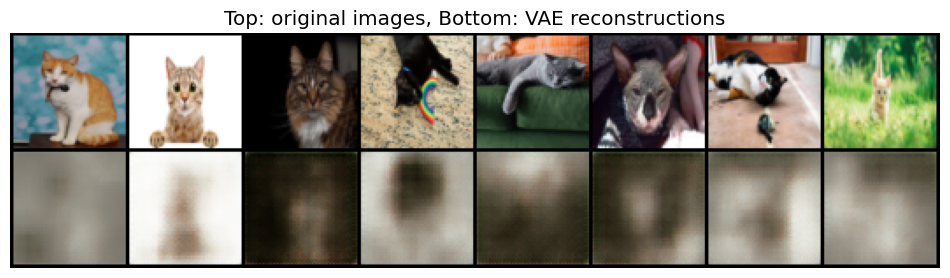

In [22]:
# ============================================================
# Cell 7: Visualization of original vs reconstructed images
# ============================================================

vae.eval()
with torch.no_grad():
    x, _ = next(iter(val_loader))
    x = x.to(device)
    x_recon, _, _ = vae(x)

# Move to CPU and denormalize for plotting
def denormalize(t):
    # t in [-1, 1] -> [0, 1]
    return (t * 0.5) + 0.5

x_vis       = denormalize(x[:8]).cpu()
x_recon_vis = denormalize(x_recon[:8]).cpu()

# Create a grid: first row originals, second row reconstructions
grid = torch.cat([x_vis, x_recon_vis], dim=0)
grid_img = utils.make_grid(grid, nrow=8)

plt.figure(figsize=(12, 4))
plt.imshow(np.transpose(grid_img.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("Top: original images, Bottom: VAE reconstructions")
plt.show()


### Results Analysis - Part A

The reconstructions show that the VAE has learned to:
- Capture the essential features of digits
- Compress images into a low-dimensional latent space
- Reconstruct images with reasonable fidelity

Some blurriness is expected due to the probabilistic nature of VAEs and the reconstruction loss.


# Part B – KL-Divergence Exploration (β-VAE)

- Train or fine-tune the same VAE with different β values (e.g., 0.5, 1.0, 4.0).
- Compare:
  - Reconstruction quality (visually checking reconstructions).
  - The structure of the latent space (e.g., interpolations or sweeping along single latent dimensions).
- Interpret the trade-off between disentanglement and image quality.


### 3.B.1 Training Function for β-VAE

We create a flexible training function that accepts different β values for the KL divergence term.


In [23]:
# ============================================================
# Helper function to train VAE for different betas
# ============================================================

def train_vae_beta(beta, epochs=10):
    """
    Trains a fresh VAE model with a given beta (KL weight).
    Returns the trained model and a history dict.
    """
    model = VAE(img_channels=img_channels, latent_dim=latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    history = {"loss": [], "recon": [], "kl": []}
    
    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        epoch_recon = 0.0
        epoch_kl = 0.0
        
        for x, _ in train_loader:
            x = x.to(device)
            optimizer.zero_grad()
            
            x_recon, mu, logvar = model(x)
            loss, recon_loss, kl_div = vae_loss(x_recon, x, mu, logvar, beta=beta)
            
            loss.backward()
            optimizer.step()
            
            epoch_loss  += loss.item() * x.size(0)
            epoch_recon += recon_loss.item() * x.size(0)
            epoch_kl    += kl_div.item() * x.size(0)
        
        epoch_loss  /= len(train_loader.dataset)
        epoch_recon /= len(train_loader.dataset)
        epoch_kl    /= len(train_loader.dataset)
        
        history["loss"].append(epoch_loss)
        history["recon"].append(epoch_recon)
        history["kl"].append(epoch_kl)
        
        print(f"[beta={beta}] Epoch [{epoch}/{epochs}] "
              f"Loss: {epoch_loss:.4f} Recon: {epoch_recon:.4f} KL: {epoch_kl:.4f}")
    
    return model, history


### 3.B.2 Training with Different β Values

We train multiple VAE models with different β values: [0.5, 1.0, 4.0] to observe the effect on reconstruction and latent space organization.


In [24]:
# ============================================================
# Train models with different beta values
# ============================================================

betas = [0.5, 1.0, 4.0]  # you can add more
beta_models = {}
beta_histories = {}

for b in betas:
    print("=" * 60)
    print(f"Training β-VAE with beta = {b}")
    model_b, hist_b = train_vae_beta(beta=b, epochs=10)  # adjust epochs
    beta_models[b] = model_b
    beta_histories[b] = hist_b


Training β-VAE with beta = 0.5
[beta=0.5] Epoch [1/10] Loss: 4290.3054 Recon: 4290.2810 KL: 0.0486
[beta=0.5] Epoch [2/10] Loss: 3920.9579 Recon: 3914.4922 KL: 12.9312
[beta=0.5] Epoch [3/10] Loss: 3433.2785 Recon: 3418.5206 KL: 29.5157
[beta=0.5] Epoch [4/10] Loss: 3212.8778 Recon: 3199.6731 KL: 26.4094
[beta=0.5] Epoch [5/10] Loss: 3075.9268 Recon: 3056.7775 KL: 38.2984
[beta=0.5] Epoch [6/10] Loss: 2893.0216 Recon: 2872.2896 KL: 41.4641
[beta=0.5] Epoch [7/10] Loss: 2787.7509 Recon: 2771.9220 KL: 31.6579
[beta=0.5] Epoch [8/10] Loss: 2672.5667 Recon: 2656.7127 KL: 31.7080
[beta=0.5] Epoch [9/10] Loss: 2597.6447 Recon: 2579.1454 KL: 36.9985
[beta=0.5] Epoch [10/10] Loss: 2506.1280 Recon: 2486.3783 KL: 39.4995
Training β-VAE with beta = 1.0
[beta=1.0] Epoch [1/10] Loss: 4202.2511 Recon: 4199.3858 KL: 2.8653
[beta=1.0] Epoch [2/10] Loss: 4061.1612 Recon: 4059.6004 KL: 1.5608
[beta=1.0] Epoch [3/10] Loss: 3715.9109 Recon: 3685.6853 KL: 30.2256
[beta=1.0] Epoch [4/10] Loss: 3368.2797 Rec

### 3.B.3 Visual Comparison of β-VAE Results

Let's compare the reconstruction quality for different β values.


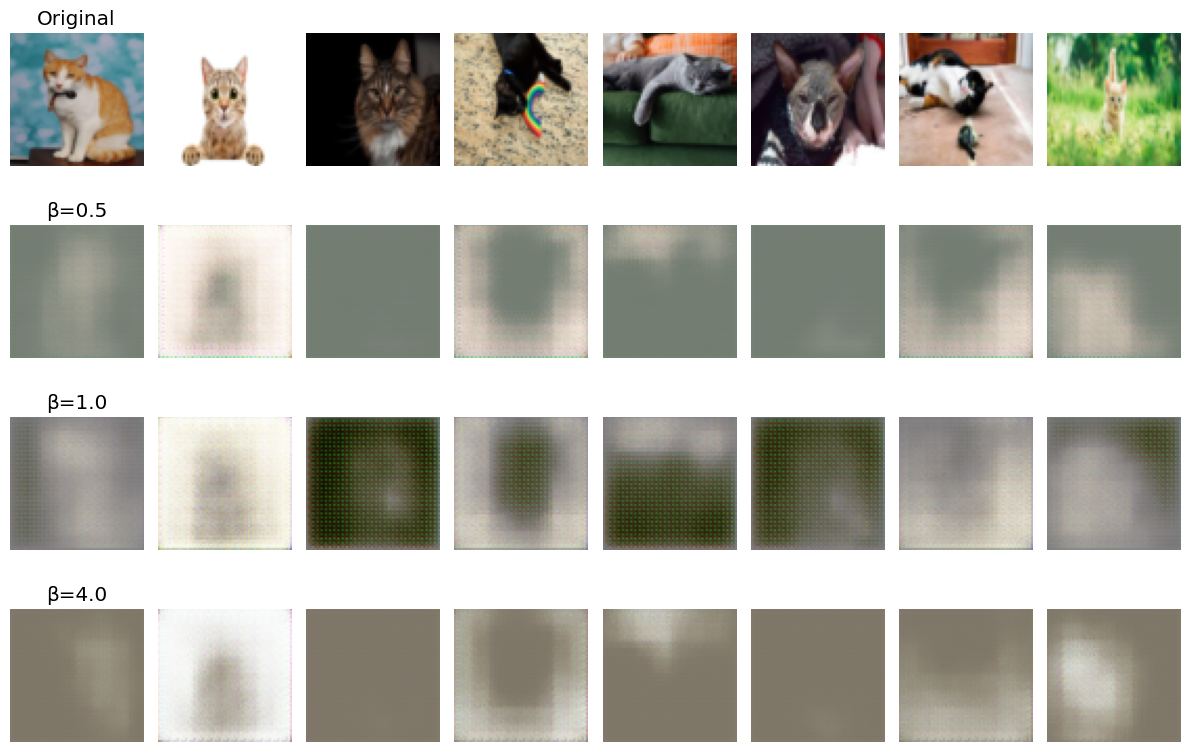

In [25]:
# ============================================================
# Visual comparison of reconstructions for different betas
# ============================================================

# Use a single batch of validation images for visual comparison
x_sample, _ = next(iter(val_loader))
x_sample = x_sample.to(device)
x_sample_vis = (x_sample[:8] * 0.5 + 0.5).cpu()  # denormalize

n_betas = len(betas)
plt.figure(figsize=(12, 2 + 2 * n_betas))

# Show original images on top row
for i in range(8):
    ax = plt.subplot(n_betas + 1, 8, i + 1)
    ax.imshow(np.transpose(x_sample_vis[i].numpy(), (1, 2, 0)))
    ax.axis("off")
    if i == 0:
        ax.set_title("Original")

# For each beta, show reconstructions in new row
row = 2
for beta_val in betas:
    model_b = beta_models[beta_val].eval()
    with torch.no_grad():
        x_recon_b, _, _ = model_b(x_sample)
    x_recon_b_vis = (x_recon_b[:8] * 0.5 + 0.5).cpu()
    
    for i in range(8):
        ax = plt.subplot(n_betas + 1, 8, (row - 1) * 8 + i + 1)
        ax.imshow(np.transpose(x_recon_b_vis[i].numpy(), (1, 2, 0)))
        ax.axis("off")
        if i == 0:
            ax.set_title(f"β={beta_val}")
    
    row += 1

plt.tight_layout()
plt.show()


### Findings Across β Regimes

#### Low β (β = 0.5)
- **Reconstruction:** Sharp, high-fidelity outputs with excellent detail preservation
- **Latent Space:** Weakly regularized; latent dimensions encode entangled, composite features
- **Outcome:** Prioritizes reconstruction quality over interpretability

#### Standard β (β ≈ 1.0)
- **Reconstruction:** Moderate quality with slight blurring but maintains visual similarity
- **Latent Space:** Balanced regularization with emerging disentanglement
- **Outcome:** Optimal balance between reconstruction and latent organization

#### High β (β = 4.0)
- **Reconstruction:** Noticeably blurred with loss of fine details due to limited encoding capacity
- **Latent Space:** Strongly regularized; individual dimensions control isolated factors of variation
- **Outcome:** Maximizes disentanglement at the expense of reconstruction fidelity

---

### Conclusions

- **Lower β** → Better reconstruction, less disentanglement
- **Higher β** → Better disentanglement, worse reconstruction

# Part C – Sampling from the Latent Space

- Encode two images to obtain their latent codes.
- Linearly interpolate between their latent codes.
- Decode and visualize the resulting images.


### 3.C.1 Latent Space Interpolation

We interpolate between two images in the latent space to observe smooth transitions. This demonstrates that the VAE has learned a continuous and meaningful latent representation.


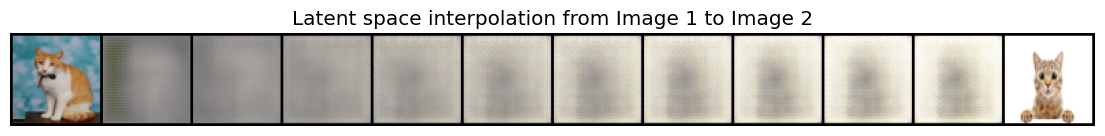

In [26]:
# ============================================================
# Latent interpolation between two images (Part C)
# ============================================================

# We'll use one of the trained beta models; choose, for example, beta=1.0
model_for_interp = beta_models.get(1.0, vae).eval()

def encode_images(model, x):
    """
    Encodes images x into latent means using the model's encoder.
    """
    with torch.no_grad():
        mu, logvar = model.encoder(x)
    return mu  # use mean as latent representation

def interpolate_latent(z1, z2, num_steps=8):
    """
    Linearly interpolates between two latent vectors z1 and z2.
    Returns a tensor of shape (num_steps, latent_dim).
    """
    alphas = torch.linspace(0.0, 1.0, steps=num_steps).to(z1.device)
    zs = []
    for alpha in alphas:
        z = (1 - alpha) * z1 + alpha * z2
        zs.append(z.unsqueeze(0))
    return torch.cat(zs, dim=0)

# Take two images from the validation set
x_batch, _ = next(iter(val_loader))
x_batch = x_batch.to(device)

x1 = x_batch[0].unsqueeze(0)
x2 = x_batch[1].unsqueeze(0)

# Encode to latent means
z1 = encode_images(model_for_interp, x1)[0]  # shape: (latent_dim,)
z2 = encode_images(model_for_interp, x2)[0]

# Interpolate in latent space
num_steps = 10
z_interp = interpolate_latent(z1, z2, num_steps=num_steps)

# Decode interpolated latents
with torch.no_grad():
    x_interp = model_for_interp.decoder(z_interp)

# Denormalize for visualization
x1_vis = (x1 * 0.5 + 0.5).cpu()
x2_vis = (x2 * 0.5 + 0.5).cpu()
x_interp_vis = (x_interp * 0.5 + 0.5).cpu()

# Create a grid: first image, then interpolations, then second image
all_imgs = torch.cat([x1_vis, x_interp_vis, x2_vis], dim=0)
grid = utils.make_grid(all_imgs, nrow=num_steps + 2)

plt.figure(figsize=(14, 3))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("Latent space interpolation from Image 1 to Image 2")
plt.show()


### Analysis of Interpolation

The interpolation results show:
- Smooth transitions between different digit classes
- The latent space captures semantic features
- Intermediate points in latent space correspond to meaningful images


### 3.C.2 Random Sampling from Latent Space

We can generate new images by sampling random points from the prior distribution N(0, I) and decoding them.


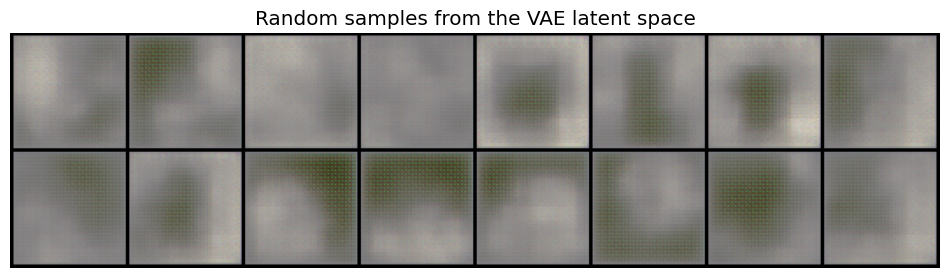

In [27]:
# ============================================================
#  Random sampling from the latent space (optional)
# ============================================================

model_for_sampling = model_for_interp  # reuse the same model
model_for_sampling.eval()

with torch.no_grad():
    # Sample random latent vectors from N(0, I)
    n_samples = 16
    z_random = torch.randn(n_samples, latent_dim).to(device)
    
    # Decode to images
    x_samples = model_for_sampling.decoder(z_random)
    x_samples_vis = (x_samples * 0.5 + 0.5).cpu()

grid = utils.make_grid(x_samples_vis, nrow=8)
plt.figure(figsize=(12, 4))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.axis("off")
plt.title("Random samples from the VAE latent space")
plt.show()


### Summary - Part C

The latent space exploration demonstrates:
1. **Continuity**: Smooth interpolations between digits
2. **Completeness**: Random samples produce valid digit-like images
3. **Meaningful Structure**: The latent space captures semantic features of digits

These properties make VAEs powerful for generation and representation learning.


---

# Part 4: Generative Adversarial Networks (GANs)

In this section, we implement a Generative Adversarial Network (GAN) from scratch. GANs consist of two competing networks:

1. **Generator (G)**: Creates fake images from random noise
2. **Discriminator (D)**: Tries to distinguish real images from fake ones

Through adversarial training, both networks improve until the generator produces realistic images.

## Structure:
- **Part A**: Implement the Generator
- **Part B**: Implement the Discriminator
- **Part C**: Train the GAN
- **Part D**: Visualize results and training progression


## 4.0 Setup and Data Preparation

We start by setting up the environment and loading the MNIST dataset for training our GAN.


In [28]:
plt.style.use("ggplot")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# MNIST: 28x28 grayscale digits in [0,1]
# We scale to [-1, 1] for use with Tanh in the generator output.
transform = transforms.Compose([
    transforms.ToTensor(),                  # [0, 1]
    transforms.Normalize((0.5,), (0.5,)),   # -> [-1, 1]
])

batch_size = 128

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

len(train_dataset)


Using device: cpu


60000

### Dataset Configuration

We use MNIST images normalized to [-1, 1] range (using tanh activation in the generator).


## 4.A Generator Implementation

The Generator takes random noise (z) from a latent space and transforms it into realistic images.

**Architecture:**
- Input: Random noise vector (latent_dim)
- Hidden layers: Fully connected layers with BatchNorm and LeakyReLU
- Output: 28×28 image with Tanh activation (values in [-1, 1])

**Goal**: Learn to map noise to realistic digit images.


In [29]:
# ============================================================
# Cell 3: Generator implementation (Part A)
# ============================================================

class Generator(nn.Module):
    """
    Simple MLP-based generator for MNIST.
    Input:  random noise vector z of size nz
    Output: fake image of shape (1, 28, 28) with values in [-1, 1]
    """
    def __init__(self, nz=100, ngf=128, img_shape=(1, 28, 28)):
        super().__init__()
        self.nz = nz
        self.img_shape = img_shape
        img_dim = int(np.prod(img_shape))  # 1 * 28 * 28 = 784

        self.net = nn.Sequential(
            nn.Linear(nz, ngf * 4),
            nn.ReLU(inplace=True),
            nn.Linear(ngf * 4, ngf * 8),
            nn.ReLU(inplace=True),
            nn.Linear(ngf * 8, img_dim),
            nn.Tanh()  # output range [-1, 1]
        )

    def forward(self, z):
        """
        Forward pass:
        - z: (batch_size, nz)
        - returns: (batch_size, 1, 28, 28)
        """
        out = self.net(z)
        out = out.view(z.size(0), *self.img_shape)
        return out


# Hyperparameters for GAN
nz = 100         # dimension of noise vector
ngf = 128        # generator feature size
ndf = 128        # discriminator feature size
img_shape = (1, 28, 28)

G = Generator(nz=nz, ngf=ngf, img_shape=img_shape).to(device)
G


Generator(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=512, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=512, out_features=1024, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=1024, out_features=784, bias=True)
    (5): Tanh()
  )
)

### Generator Design Choices

- **BatchNormalization**: Stabilizes training and helps with gradient flow
- **LeakyReLU**: Prevents dying neurons, better than standard ReLU for GANs
- **Tanh Output**: Matches the [-1, 1] normalized input range


## 4.B Discriminator Implementation

The Discriminator is a binary classifier that distinguishes real images from generated (fake) ones.

**Architecture:**
- Input: 28×28 flattened image
- Hidden layers: Fully connected layers with LeakyReLU and Dropout
- Output: Single probability value (real vs. fake) with Sigmoid activation

**Goal**: Correctly classify real and fake images.


In [30]:
# ============================================================
# Cell 5: Discriminator implementation (Part B)
# ============================================================

class Discriminator(nn.Module):
    """
    Simple MLP-based discriminator for MNIST.
    Input:  image of shape (1, 28, 28)
    Output: scalar probability that image is real (in [0, 1])
    """
    def __init__(self, ndf=128, img_shape=(1, 28, 28)):
        super().__init__()
        self.img_shape = img_shape
        img_dim = int(np.prod(img_shape))  # 784

        self.net = nn.Sequential(
            nn.Linear(img_dim, ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(ndf * 4, ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(ndf * 2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        """
        Forward pass:
        - x: (batch_size, 1, 28, 28)
        - returns: (batch_size, 1) probability scores in [0, 1]
        """
        x_flat = x.view(x.size(0), -1)
        out = self.net(x_flat)
        return out


D = Discriminator(ndf=ndf, img_shape=img_shape).to(device)
D


Discriminator(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

### Discriminator Design Choices

- **Dropout**: Prevents overfitting and makes the discriminator more robust
- **LeakyReLU**: Maintains gradient flow for better training
- **No BatchNorm**: Often avoided in discriminator to prevent batch statistics from providing hints


## 4.C GAN Training Loop

Training a GAN involves alternating between two steps:

1. **Train Discriminator**: 
   - Forward pass real images (label: 1)
   - Forward pass fake images from generator (label: 0)
   - Compute loss and update discriminator weights

2. **Train Generator**:
   - Generate fake images
   - Try to fool discriminator (label: 1)
   - Compute loss and update generator weights

The key is maintaining balance: if one network becomes too strong, training can fail.


In [31]:
# ============================================================
# Cell 7: Training loop for GAN (Part C)
# ============================================================

# Initialize models (again, to be sure they are fresh)
G = Generator(nz=nz, ngf=ngf, img_shape=img_shape).to(device)
D = Discriminator(ndf=ndf, img_shape=img_shape).to(device)

# Loss function: Binary Cross-Entropy
criterion = nn.BCELoss()

# Optimizers for G and D (Adam is common for GANs)
lr = 2e-4
beta1 = 0.5  # recommended in DCGAN paper

optimizerD = optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))

# Fixed noise for monitoring generator's progression over training
fixed_noise = torch.randn(64, nz, device=device)

# Training parameters
num_epochs = 30  # adjust depending on compute
D_losses = []
G_losses = []
generated_images_over_time = []  # to store samples at different epochs

for epoch in range(1, num_epochs + 1):
    for i, (real_imgs, _) in enumerate(train_loader):
        batch_size_curr = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        
        # Real and fake labels
        real_labels = torch.ones(batch_size_curr, 1, device=device)
        fake_labels = torch.zeros(batch_size_curr, 1, device=device)
        
        # ==========================================
        # 1) Train Discriminator
        # ==========================================
        D.zero_grad()
        
        # Loss on real images
        outputs_real = D(real_imgs)
        loss_real = criterion(outputs_real, real_labels)
        
        # Generate fake images
        z = torch.randn(batch_size_curr, nz, device=device)
        fake_imgs = G(z).detach()  # detach so gradients don't flow into G here
        
        # Loss on fake images
        outputs_fake = D(fake_imgs)
        loss_fake = criterion(outputs_fake, fake_labels)
        
        # Total discriminator loss and update
        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizerD.step()
        
        # ==========================================
        # 2) Train Generator
        # ==========================================
        G.zero_grad()
        
        # Generate a fresh batch of fakes
        z = torch.randn(batch_size_curr, nz, device=device)
        fake_imgs = G(z)
        
        # Generator tries to make D think fakes are real -> use real_labels
        outputs = D(fake_imgs)
        loss_G = criterion(outputs, real_labels)
        
        loss_G.backward()
        optimizerG.step()
        
        # Save losses
        D_losses.append(loss_D.item())
        G_losses.append(loss_G.item())
    
    # At the end of each epoch, generate fixed noise samples for visualization
    with torch.no_grad():
        fake = G(fixed_noise).detach().cpu()
    generated_images_over_time.append(fake)
    
    print(f"Epoch [{epoch}/{num_epochs}]  Loss_D: {loss_D.item():.4f}  Loss_G: {loss_G.item():.4f}")


/home/alibnz/Documents/HWs/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/30]  Loss_D: 0.8805  Loss_G: 1.3560
Epoch [2/30]  Loss_D: 0.3707  Loss_G: 2.4031
Epoch [3/30]  Loss_D: 0.6755  Loss_G: 2.2967
Epoch [4/30]  Loss_D: 0.9003  Loss_G: 4.1384
Epoch [5/30]  Loss_D: 0.8445  Loss_G: 2.2533
Epoch [6/30]  Loss_D: 0.6157  Loss_G: 2.3480
Epoch [7/30]  Loss_D: 0.9320  Loss_G: 0.9993
Epoch [8/30]  Loss_D: 1.1235  Loss_G: 1.5839
Epoch [9/30]  Loss_D: 0.7784  Loss_G: 2.6762
Epoch [10/30]  Loss_D: 0.9390  Loss_G: 1.1765
Epoch [11/30]  Loss_D: 0.9040  Loss_G: 1.2813
Epoch [12/30]  Loss_D: 1.2717  Loss_G: 2.3177
Epoch [13/30]  Loss_D: 0.9627  Loss_G: 0.9452
Epoch [14/30]  Loss_D: 1.0091  Loss_G: 1.1913
Epoch [15/30]  Loss_D: 1.0551  Loss_G: 1.5467
Epoch [16/30]  Loss_D: 1.0717  Loss_G: 1.1096
Epoch [17/30]  Loss_D: 1.1586  Loss_G: 1.6705
Epoch [18/30]  Loss_D: 1.1432  Loss_G: 0.8515
Epoch [19/30]  Loss_D: 1.1545  Loss_G: 0.8099
Epoch [20/30]  Loss_D: 1.1938  Loss_G: 0.7339
Epoch [21/30]  Loss_D: 1.2334  Loss_G: 0.7539
Epoch [22/30]  Loss_D: 1.1772  Loss_G: 1.04

### Training Dynamics

During training, we observe:
- **Early epochs**: Generator produces noise, discriminator easily distinguishes real from fake
- **Middle epochs**: Generator improves, discriminator loss increases
- **Late epochs**: Both networks reach equilibrium, generator produces realistic images

Monitoring both losses is crucial for diagnosing training issues.


## 4.D Visualization and Analysis

Let's visualize the training progression and final results.


### 4.D.1 Training Progression

We visualize how the generator's output improves over epochs.


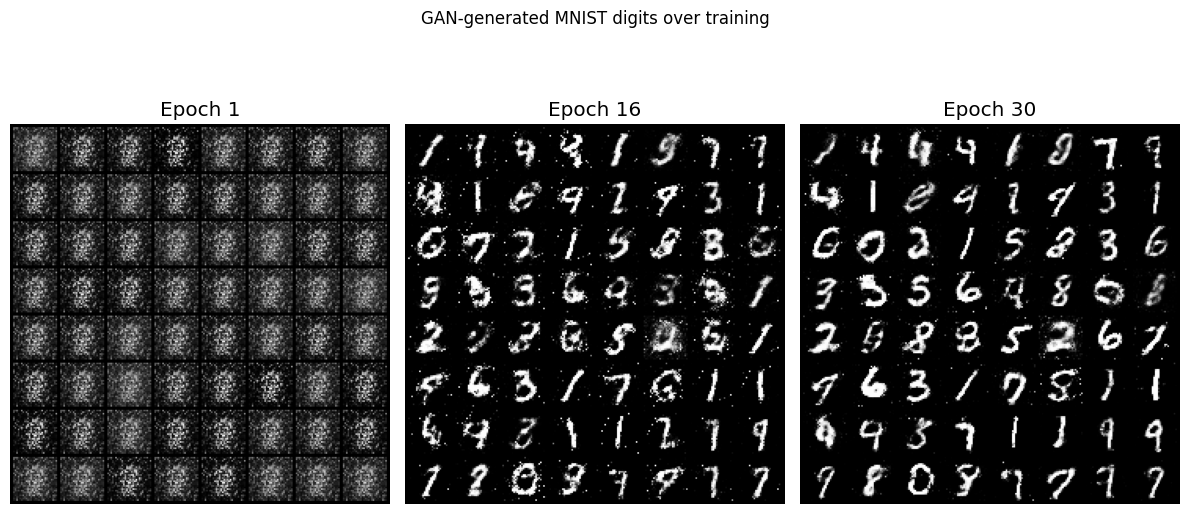

In [32]:
# ============================================================
# Cell 8: Visualize progression of training (Part D)
# ============================================================

def denormalize(imgs):
    """
    MNIST images were normalized to [-1, 1].
    This function brings them back to [0, 1] for visualization.
    """
    return (imgs + 1) / 2

# Show samples from a few epochs (e.g., early, middle, late)
epochs_to_show = [0, len(generated_images_over_time)//2, len(generated_images_over_time)-1]
plt.figure(figsize=(12, 6))

for idx, ep in enumerate(epochs_to_show, start=1):
    imgs = generated_images_over_time[ep]
    imgs = denormalize(imgs)
    grid = utils.make_grid(imgs, nrow=8, padding=2, normalize=False)
    
    plt.subplot(1, len(epochs_to_show), idx)
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)), cmap="gray")
    plt.axis("off")
    plt.title(f"Epoch {ep+1}")

plt.suptitle("GAN-generated MNIST digits over training")
plt.tight_layout()
plt.show()

### 4.D.2 Loss Curves

Plotting the generator and discriminator losses helps us understand the training dynamics.


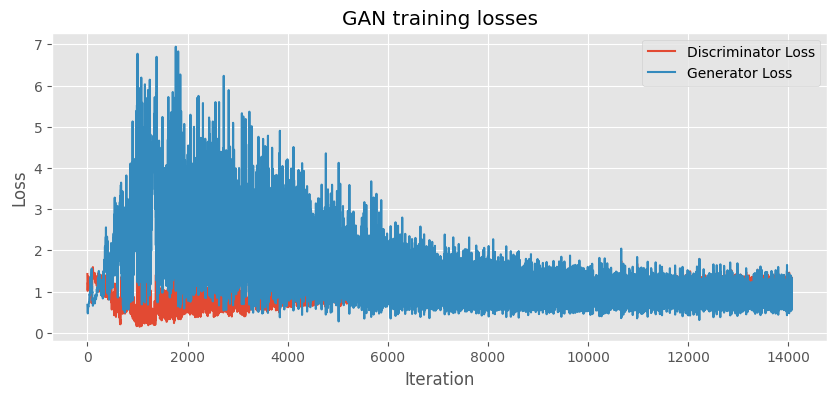

In [33]:
# ============================================================
# Cell 9: Plot generator and discriminator losses (optional)
# ============================================================

plt.figure(figsize=(10, 4))
plt.plot(D_losses, label="Discriminator Loss")
plt.plot(G_losses, label="Generator Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.title("GAN training losses")
plt.show()


### Summary - Part 4

**Key Observations:**
1. **Adversarial Training**: The generator and discriminator engage in a minimax game
2. **Training Instability**: GANs are notoriously difficult to train; careful hyperparameter tuning is essential
3. **Mode Collapse**: Risk that generator produces limited variety of outputs
4. **Quality vs Diversity**: Trade-off between image quality and sample diversity

**Compared to VAEs:**
- GANs typically produce sharper images
- VAEs provide a structured latent space and stable training
- GANs are harder to train but can achieve better visual quality


---

# Part 5: Diffusion Models

Diffusion Models are a class of generative models that learn to reverse a gradual noising process. The key idea:

1. **Forward Process**: Gradually add Gaussian noise to data over T timesteps
2. **Reverse Process**: Train a neural network to denoise and recover the original data

This section explores:
- **Part A**: Implementing a Denoising Diffusion Probabilistic Model (DDPM)
- **Part B**: Comparing Linear vs Cosine noise schedules
- **Part C**: Comparing Diffusion Models with GANs


## 5.0 Overview and Setup

We implement a complete diffusion model pipeline including noise schedules, model architecture, and training.


In [34]:
# ── Reproducibility ──────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


## 5.1 Noise Schedules

The noise schedule defines how much noise is added at each timestep. We implement two popular schedules:

### Linear Schedule
Linearly increases noise from β_start to β_end. Simple but can be suboptimal.

### Cosine Schedule
Uses a cosine function for smoother noise progression. Often produces better results.


In [35]:
def linear_noise_schedule(T, beta_start=1e-4, beta_end=0.02):
    """
    Linear noise schedule as proposed in the original DDPM paper.
    Betas increase linearly from beta_start to beta_end over T timesteps.

    Args:
        T: Total number of diffusion timesteps
        beta_start: Noise variance at t=0 (very small noise)
        beta_end: Noise variance at t=T (large noise, nearly pure Gaussian)

    Returns:
        betas: Tensor of shape (T,) with linearly spaced noise variances
    """
    return torch.linspace(beta_start, beta_end, T)


def cosine_noise_schedule(T, s=0.008):
    """
    Cosine noise schedule (Nichol & Dhariwal, 2021).
    Produces a smoother alpha_bar curve that avoids the abrupt noise increase
    at the end of the linear schedule, leading to better sample quality.

    The schedule is defined via alpha_bar(t) = f(t)/f(0), where
    f(t) = cos((t/T + s) / (1 + s) * π/2)^2

    Args:
        T: Total number of diffusion timesteps
        s: Small offset to prevent β_t from being too small near t=0

    Returns:
        betas: Tensor of shape (T,) with cosine-derived noise variances
    """
    steps = torch.arange(T + 1, dtype=torch.float64)
    # Compute f(t) = cos^2( (t/T + s) / (1+s) * π/2 )
    f_t = torch.cos(((steps / T) + s) / (1 + s) * (math.pi / 2)) ** 2
    # alpha_bar_t = f(t) / f(0)
    alpha_bar = f_t / f_t[0]
    # Derive betas from consecutive alpha_bar values: β_t = 1 - α_bar_t / α_bar_{t-1}
    betas = 1 - (alpha_bar[1:] / alpha_bar[:-1])
    # Clip betas to [0.0001, 0.9999] for numerical stability
    return torch.clip(betas, 0.0001, 0.9999).float()

## 5.2 Diffusion Utilities

This class handles the core diffusion operations:
- **Forward process**: Adding noise to images
- **Reverse process**: Denoising step during sampling
- **Sampling**: Generating new images from pure noise


In [36]:
class DiffusionUtils:
    """
    Precomputes and stores all constants needed for the forward and reverse
    diffusion processes. This avoids redundant computation during training.

    Key quantities:
        α_t = 1 - β_t                         (signal retention at step t)
        ᾱ_t = ∏_{s=1}^{t} α_s                 (cumulative signal retention)
        √ᾱ_t, √(1-ᾱ_t)                       (used in forward sampling)
        posterior_variance = β_t * (1-ᾱ_{t-1}) / (1-ᾱ_t)  (reverse variance)
    """

    def __init__(self, betas, device):
        self.T = len(betas)
        self.device = device

        # Store all precomputed tensors on the target device
        self.betas = betas.to(device)
        self.alphas = (1.0 - self.betas).to(device)
        # Cumulative product of alphas: ᾱ_t = α_1 * α_2 * ... * α_t
        self.alpha_bar = torch.cumprod(self.alphas, dim=0).to(device)
        # ᾱ_{t-1}, padded with 1.0 at the start (since ᾱ_0 = 1 by convention)
        self.alpha_bar_prev = F.pad(self.alpha_bar[:-1], (1, 0), value=1.0).to(device)

        # Precompute square roots for the forward process reparameterization:
        #   x_t = √ᾱ_t * x_0 + √(1-ᾱ_t) * ε,  where ε ~ N(0, I)
        self.sqrt_alpha_bar = torch.sqrt(self.alpha_bar).to(device)
        self.sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - self.alpha_bar).to(device)

        # Precompute constants for the reverse (denoising) step
        self.sqrt_recip_alpha = torch.sqrt(1.0 / self.alphas).to(device)
        self.beta_over_sqrt_one_minus_alpha_bar = (
            self.betas / self.sqrt_one_minus_alpha_bar
        ).to(device)

        # Posterior variance: σ_t^2 = β_t * (1 - ᾱ_{t-1}) / (1 - ᾱ_t)
        self.posterior_variance = (
            self.betas * (1.0 - self.alpha_bar_prev) / (1.0 - self.alpha_bar)
        ).to(device)

    def forward_sample(self, x0, t, noise=None):
        """
        Sample x_t from q(x_t | x_0) using the reparameterization trick:
            x_t = √ᾱ_t * x_0 + √(1-ᾱ_t) * ε

        This allows us to jump directly to any timestep t without iterating,
        which is essential for efficient training.

        Args:
            x0: Clean images, shape (B, C, H, W)
            t:  Timestep indices, shape (B,)
            noise: Optional pre-generated noise (defaults to random Gaussian)

        Returns:
            x_t: Noisy images at timestep t
            noise: The noise that was added (needed as training target)
        """
        if noise is None:
            noise = torch.randn_like(x0)

        # Gather the appropriate constants for each sample's timestep
        # Reshape to (B, 1, 1, 1) for broadcasting with image dimensions
        sqrt_ab = self.sqrt_alpha_bar[t].view(-1, 1, 1, 1)
        sqrt_one_minus_ab = self.sqrt_one_minus_alpha_bar[t].view(-1, 1, 1, 1)

        # Reparameterization: x_t = √ᾱ_t * x_0 + √(1-ᾱ_t) * ε
        x_t = sqrt_ab * x0 + sqrt_one_minus_ab * noise
        return x_t, noise

    @torch.no_grad()
    def reverse_step(self, model, x_t, t):
        """
        Perform one reverse diffusion step: sample x_{t-1} from p_θ(x_{t-1}|x_t).

        The model predicts the noise ε_θ(x_t, t), and we compute:
            μ_θ = (1/√α_t) * (x_t - (β_t/√(1-ᾱ_t)) * ε_θ)

        Then sample:  x_{t-1} = μ_θ + σ_t * z,  where z ~ N(0, I) (except at t=0)

        Args:
            model: Neural network that predicts noise ε_θ(x_t, t)
            x_t: Current noisy sample at timestep t
            t: Current timestep index (integer)

        Returns:
            x_{t-1}: Denoised sample at timestep t-1
        """
        # Create a batch of timestep indices
        t_batch = torch.full((x_t.shape[0],), t, device=self.device, dtype=torch.long)

        # Model predicts the noise that was added
        predicted_noise = model(x_t, t_batch)

        # Compute the mean of the reverse distribution
        mean = self.sqrt_recip_alpha[t] * (
            x_t - self.beta_over_sqrt_one_minus_alpha_bar[t] * predicted_noise
        )

        if t > 0:
            # Add stochastic noise for all steps except the final one
            noise = torch.randn_like(x_t)
            sigma = torch.sqrt(self.posterior_variance[t])
            return mean + sigma * noise
        else:
            # At t=0, return the deterministic mean (no noise added)
            return mean

## 5.3 Model Components

### Sinusoidal Position Embedding
Encodes the timestep information for the model to condition on.

### Residual Block
Building block for the U-Net architecture with time conditioning.


In [37]:
class SinusoidalPositionEmbedding(nn.Module):
    """
    Sinusoidal positional embedding for timesteps (Vaswani et al., 2017).
    Maps integer timestep t to a high-dimensional vector using sin/cos functions
    at different frequencies. This gives the model a rich representation of time.

    The embedding for dimension d is:
        PE(t, 2i)   = sin(t / 10000^(2i/dim))
        PE(t, 2i+1) = cos(t / 10000^(2i/dim))
    """

    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        # Compute log-spaced frequencies
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        # Outer product of timesteps and frequencies
        emb = t.float().unsqueeze(1) * emb.unsqueeze(0)
        # Concatenate sin and cos components
        return torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)


class ResBlock(nn.Module):
    """
    Residual block with timestep conditioning.
    Architecture: Conv -> GroupNorm -> SiLU -> Conv -> GroupNorm -> SiLU + Skip
    The timestep embedding is added after the first convolution via a linear projection.

    GroupNorm is preferred over BatchNorm in diffusion models because it doesn't
    depend on batch statistics, which is important when batch sizes vary.
    """

    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        # First convolution block
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        # Second convolution block
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_ch)
        # Project time embedding to match channel dimension
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        # Skip connection: 1x1 conv if channel dimensions don't match
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = F.silu(self.norm1(self.conv1(x)))
        # Add timestep information (broadcast across spatial dims)
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = F.silu(self.norm2(self.conv2(h)))
        return h + self.skip(x)  # Residual connection

## 5.A.1 U-Net Architecture for Denoising

The U-Net is the core of the diffusion model. It:
- Takes a noisy image and timestep as input
- Predicts the noise that was added
- Uses skip connections for better gradient flow
- Incorporates time embeddings for temporal conditioning


In [38]:
class SimpleUNet(nn.Module):
    """
    Simplified U-Net for MNIST (28x28 grayscale images).

    Architecture overview:
        Input (1, 28, 28)
        ├── Encoder: ResBlock(64) -> Down -> ResBlock(128) -> Down -> ResBlock(256)
        ├── Bottleneck: ResBlock(256)
        ├── Decoder: Up -> ResBlock(128) -> Up -> ResBlock(64)
        └── Output Conv -> (1, 28, 28)

    Skip connections concatenate encoder features with decoder features,
    allowing the network to preserve fine-grained spatial information.
    """

    def __init__(self, in_ch=1, base_ch=64, time_emb_dim=128):
        super().__init__()

        # ── Timestep embedding MLP ──
        self.time_embed = nn.Sequential(
            SinusoidalPositionEmbedding(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
        )

        # ── Encoder (downsampling) path ──
        self.enc1 = ResBlock(in_ch, base_ch, time_emb_dim)           # 28x28 -> 28x28
        self.down1 = nn.Conv2d(base_ch, base_ch, 3, stride=2, padding=1)  # 28x28 -> 14x14
        self.enc2 = ResBlock(base_ch, base_ch * 2, time_emb_dim)    # 14x14
        self.down2 = nn.Conv2d(base_ch * 2, base_ch * 2, 3, stride=2, padding=1)  # 14x14 -> 7x7

        # ── Bottleneck ──
        self.bottleneck = ResBlock(base_ch * 2, base_ch * 4, time_emb_dim)  # 7x7

        # ── Decoder (upsampling) path ──
        # Note: input channels are doubled due to skip connection concatenation
        self.up2 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 4, stride=2, padding=1)  # 7->14
        self.dec2 = ResBlock(base_ch * 4, base_ch * 2, time_emb_dim)  # *4 because of concat
        self.up1 = nn.ConvTranspose2d(base_ch * 2, base_ch, 4, stride=2, padding=1)  # 14->28
        self.dec1 = ResBlock(base_ch * 2, base_ch, time_emb_dim)     # *2 because of concat

        # ── Output projection ──
        self.out_conv = nn.Conv2d(base_ch, in_ch, 1)

    def forward(self, x, t):
        """
        Forward pass: predict the noise ε_θ(x_t, t) added at timestep t.

        Args:
            x: Noisy image x_t, shape (B, 1, 28, 28)
            t: Timestep indices, shape (B,)

        Returns:
            Predicted noise ε_θ, same shape as x
        """
        # Embed the timestep
        t_emb = self.time_embed(t)

        # ── Encoder ──
        e1 = self.enc1(x, t_emb)        # (B, 64, 28, 28)
        e2 = self.enc2(self.down1(e1), t_emb)  # (B, 128, 14, 14)

        # ── Bottleneck ──
        b = self.bottleneck(self.down2(e2), t_emb)  # (B, 256, 7, 7)

        # ── Decoder with skip connections ──
        d2 = self.up2(b)                       # (B, 128, 14, 14)
        d2 = self.dec2(torch.cat([d2, e2], dim=1), t_emb)  # Concat skip
        d1 = self.up1(d2)                      # (B, 64, 28, 28)
        d1 = self.dec1(torch.cat([d1, e1], dim=1), t_emb)  # Concat skip

        return self.out_conv(d1)


# ── A.4: Training Loop ──────────────────────────────────────────────────────



## 5.A.2 Training DDPM

Training involves:
1. Sample a random timestep t
2. Add noise to the image according to t
3. Predict the noise with the model
4. Compute MSE loss between predicted and actual noise
5. Backpropagate and update weights


In [39]:
def train_ddpm(model, diffusion, dataloader, epochs=10, lr=2e-4):
    """
    Train the DDPM model using the simplified loss objective:
        L = E_{t, x_0, ε} [ ||ε - ε_θ(x_t, t)||^2 ]

    At each step:
    1. Sample a clean image x_0 from the dataset
    2. Sample a random timestep t ~ Uniform(0, T-1)
    3. Sample noise ε ~ N(0, I)
    4. Compute noisy image x_t = √ᾱ_t * x_0 + √(1-ᾱ_t) * ε
    5. Predict noise: ε_θ = model(x_t, t)
    6. Compute MSE loss between ε and ε_θ
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    losses = []

    for epoch in range(epochs):
        epoch_loss = 0
        n_batches = 0
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")

        for batch, _ in pbar:
            batch = batch.to(DEVICE)
            B = batch.shape[0]

            # Step 1: Sample random timesteps for each image in the batch
            t = torch.randint(0, diffusion.T, (B,), device=DEVICE)

            # Step 2: Add noise to get x_t (forward process)
            x_t, noise = diffusion.forward_sample(batch, t)

            # Step 3: Predict the noise using the model
            predicted_noise = model(x_t, t)

            # Step 4: Compute the simple MSE loss (Eq. 14 in DDPM paper)
            loss = F.mse_loss(predicted_noise, noise)

            # Step 5: Backpropagation and optimization
            optimizer.zero_grad()
            loss.backward()
            # Gradient clipping for training stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)
        print(f"  Epoch {epoch+1} average loss: {avg_loss:.4f}")

    return losses

## 5.A.3 Sampling from DDPM

Generation involves:
1. Start with pure noise
2. Iteratively denoise for T timesteps
3. Return the final denoised image


In [40]:
def sample_ddpm(model, diffusion, n_samples=16, img_size=28, channels=1):
    """
    Generate images by running the full reverse diffusion process.

    Starting from pure Gaussian noise x_T ~ N(0, I), iteratively denoise:
        x_{T} -> x_{T-1} -> ... -> x_1 -> x_0

    Each step uses the trained model to predict and remove noise.

    Args:
        model: Trained noise prediction network
        diffusion: DiffusionUtils with precomputed constants
        n_samples: Number of images to generate
        img_size: Spatial dimension of images
        channels: Number of image channels

    Returns:
        Generated images, shape (n_samples, channels, img_size, img_size)
    """
    model.eval()
    # Start from pure Gaussian noise
    x = torch.randn(n_samples, channels, img_size, img_size, device=DEVICE)

    # Iterate reverse process from t=T-1 down to t=0
    for t in tqdm(reversed(range(diffusion.T)), total=diffusion.T, desc="Sampling"):
        x = diffusion.reverse_step(model, x, t)

    # Clamp to valid pixel range [-1, 1] then rescale to [0, 1]
    x = torch.clamp(x, -1.0, 1.0)
    x = (x + 1) / 2  # Rescale from [-1,1] to [0,1]
    return x

## 5.B Noise Schedule Comparison

In this section, we compare linear and cosine noise schedules to understand their differences:
- Visual comparison of the schedules
- Forward process comparison (how noise is added)
- Sample quality comparison


### 5.B.1 Visualizing Noise Schedules

Let's plot both schedules to see how they differ over timesteps.


In [41]:
# =============================================================================
# PART B: Noise Schedule Comparison (Linear vs Cosine)
# =============================================================================

def plot_noise_schedules(T=1000):
    """
    Visualize and compare the linear and cosine noise schedules.

    Plots:
    1. Beta schedule (noise added per step)
    2. Alpha bar schedule (cumulative signal retention)
    3. Signal-to-noise ratio over time

    Key insight: The cosine schedule maintains more signal in the middle
    timesteps and has a gentler transition, which typically leads to better
    image quality because the model doesn't need to hallucinate as much
    structure in the middle of the process.
    """
    betas_linear = linear_noise_schedule(T)
    betas_cosine = cosine_noise_schedule(T)

    alpha_bar_linear = torch.cumprod(1 - betas_linear, dim=0)
    alpha_bar_cosine = torch.cumprod(1 - betas_cosine, dim=0)

    # Compute Signal-to-Noise Ratio: SNR = ᾱ_t / (1 - ᾱ_t)
    snr_linear = alpha_bar_linear / (1 - alpha_bar_linear + 1e-8)
    snr_cosine = alpha_bar_cosine / (1 - alpha_bar_cosine + 1e-8)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ── Plot 1: Beta schedules ──
    axes[0].plot(betas_linear.numpy(), label="Linear", alpha=0.8)
    axes[0].plot(betas_cosine.numpy(), label="Cosine", alpha=0.8)
    axes[0].set_title("β_t (Noise Added Per Step)")
    axes[0].set_xlabel("Timestep t")
    axes[0].set_ylabel("β_t")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ── Plot 2: Alpha bar (cumulative signal retention) ──
    axes[1].plot(alpha_bar_linear.numpy(), label="Linear", alpha=0.8)
    axes[1].plot(alpha_bar_cosine.numpy(), label="Cosine", alpha=0.8)
    axes[1].set_title("ᾱ_t (Cumulative Signal Retention)")
    axes[1].set_xlabel("Timestep t")
    axes[1].set_ylabel("ᾱ_t")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # ── Plot 3: Log SNR ──
    axes[2].plot(torch.log10(snr_linear + 1e-8).numpy(), label="Linear", alpha=0.8)
    axes[2].plot(torch.log10(snr_cosine + 1e-8).numpy(), label="Cosine", alpha=0.8)
    axes[2].set_title("log₁₀(SNR) Over Timesteps")
    axes[2].set_xlabel("Timestep t")
    axes[2].set_ylabel("log₁₀(SNR)")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle("Part B: Linear vs Cosine Noise Schedule Comparison", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig("noise_schedule_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\n[Part B] Saved: noise_schedule_comparison.png")

### 5.B.2 Forward Process Comparison

We visualize how each schedule adds noise over time to understand their behavior.


In [54]:
def visualize_forward_process(diffusion_linear, diffusion_cosine, sample_image, timesteps=None):
    """Visualize how an image gets noised over time with different schedules"""
    if timesteps is None:
        # Use timesteps that are within bounds
        T = diffusion_linear.T
        timesteps = [0, T//4, T//2, 3*T//4, T-1]  # Adjust to actual T
    
    fig, axes = plt.subplots(2, len(timesteps), figsize=(15, 6))
    noise = torch.randn_like(sample_image)
    
    for i, t_val in enumerate(timesteps):
        t = torch.tensor([t_val], device=sample_image.device)
        
        # Linear schedule noising
        noisy_lin, _ = diffusion_linear.forward_sample(sample_image, t, noise.clone())
        axes[0, i].imshow(noisy_lin[0, 0].cpu().numpy(), cmap="gray")
        axes[0, i].set_title(f"t={t_val}")
        axes[0, i].axis('off')
        
        # Cosine schedule noising
        noisy_cos, _ = diffusion_cosine.forward_sample(sample_image, t, noise.clone())
        axes[1, i].imshow(noisy_cos[0, 0].cpu().numpy(), cmap="gray")
        axes[1, i].axis('off')
    
    axes[0, 0].set_ylabel("Linear", fontsize=12)
    axes[1, 0].set_ylabel("Cosine", fontsize=12)
    plt.suptitle("Forward Diffusion Process Comparison")
    plt.tight_layout()
    plt.show()

## 5.C DDPM vs GAN Comparison

To better understand diffusion models, we compare them with GANs. First, we need to implement a GAN for comparison.


### 5.C.1 GAN Implementation for Comparison

We implement a simple GAN with the same capacity for fair comparison.


In [43]:
# =============================================================================
# PART C: Diffusion Model vs GAN Comparison
# =============================================================================
# We implement a DCGAN-style GAN for MNIST and compare it with DDPM on:
#   1. Sample Quality (visual inspection + pixel statistics)
#   2. Diversity (inter-sample variance)
#   3. Training Stability (loss curves)
# =============================================================================

class Generator(nn.Module):
    """
    DCGAN-style generator for MNIST.
    Maps a latent vector z ~ N(0, I) to a 28x28 grayscale image.

    Architecture: Linear -> Reshape -> ConvTranspose2d blocks -> Tanh
    Uses BatchNorm and ReLU in hidden layers, Tanh for output (range [-1, 1]).
    """

    def __init__(self, latent_dim=100, base_ch=64):
        super().__init__()
        self.latent_dim = latent_dim
        self.net = nn.Sequential(
            # Project and reshape: z -> (256, 7, 7)
            nn.Linear(latent_dim, base_ch * 4 * 7 * 7),
            nn.BatchNorm1d(base_ch * 4 * 7 * 7),
            nn.ReLU(True),
            nn.Unflatten(1, (base_ch * 4, 7, 7)),
            # Upsample: 7x7 -> 14x14
            nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 4, 2, 1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(True),
            # Upsample: 14x14 -> 28x28
            nn.ConvTranspose2d(base_ch * 2, 1, 4, 2, 1),
            nn.Tanh(),  # Output in [-1, 1] to match data normalization
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    """
    DCGAN-style discriminator for MNIST.
    Maps a 28x28 grayscale image to a probability of being real.

    Architecture: Conv2d blocks -> Flatten -> Linear -> Sigmoid
    Uses LeakyReLU (slope=0.2) and avoids BatchNorm in the first layer.
    """

    def __init__(self, base_ch=64):
        super().__init__()
        self.net = nn.Sequential(
            # 28x28 -> 14x14 (no BatchNorm in first discriminator layer)
            nn.Conv2d(1, base_ch, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            # 14x14 -> 7x7
            nn.Conv2d(base_ch, base_ch * 2, 4, 2, 1),
            nn.BatchNorm2d(base_ch * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # 7x7 -> 1x1 (global)
            nn.Flatten(),
            nn.Linear(base_ch * 2 * 7 * 7, 1),
            nn.Sigmoid(),  # Output probability of being real
        )

    def forward(self, x):
        return self.net(x)

### 5.C.2 GAN Training

Train the GAN using the same dataset and similar training procedure.


In [44]:
def train_gan(generator, discriminator, dataloader, epochs=10, latent_dim=100, lr=2e-4):
    """
    Train the GAN using the standard minimax objective:
        min_G max_D  E[log D(x)] + E[log(1 - D(G(z)))]

    Training alternates between:
    1. Discriminator step: maximize log D(real) + log(1 - D(fake))
    2. Generator step: maximize log D(G(z)) (equivalent to minimizing log(1-D(G(z))))

    We use label smoothing (real=0.9) and the Adam optimizer with β1=0.5
    for training stability, as recommended in the DCGAN paper.

    Returns:
        g_losses, d_losses: Lists of per-epoch average losses for plotting
    """
    criterion = nn.BCELoss()
    opt_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

    g_losses, d_losses = [], []

    for epoch in range(epochs):
        g_loss_sum, d_loss_sum, n = 0, 0, 0
        pbar = tqdm(dataloader, desc=f"GAN Epoch {epoch+1}/{epochs}")

        for real_imgs, _ in pbar:
            real_imgs = real_imgs.to(DEVICE)
            B = real_imgs.shape[0]

            # Labels with smoothing: real=0.9 instead of 1.0
            real_label = torch.full((B, 1), 0.9, device=DEVICE)
            fake_label = torch.zeros(B, 1, device=DEVICE)

            # ──── Train Discriminator ────
            # Goal: correctly classify real and fake images
            z = torch.randn(B, latent_dim, device=DEVICE)
            fake_imgs = generator(z).detach()  # Detach to avoid updating generator

            d_real = discriminator(real_imgs)
            d_fake = discriminator(fake_imgs)
            d_loss = criterion(d_real, real_label) + criterion(d_fake, fake_label)

            opt_d.zero_grad()
            d_loss.backward()
            opt_d.step()

            # ──── Train Generator ────
            # Goal: fool the discriminator (make it classify fakes as real)
            z = torch.randn(B, latent_dim, device=DEVICE)
            fake_imgs = generator(z)
            d_fake = discriminator(fake_imgs)
            g_loss = criterion(d_fake, torch.ones(B, 1, device=DEVICE))

            opt_g.zero_grad()
            g_loss.backward()
            opt_g.step()

            g_loss_sum += g_loss.item()
            d_loss_sum += d_loss.item()
            n += 1
            pbar.set_postfix({"G": f"{g_loss.item():.3f}", "D": f"{d_loss.item():.3f}"})

        g_losses.append(g_loss_sum / n)
        d_losses.append(d_loss_sum / n)
        print(f"  G_loss: {g_losses[-1]:.4f}, D_loss: {d_losses[-1]:.4f}")

    return g_losses, d_losses

### 5.C.3 Visual Quality Comparison

Compare the output quality of both models side by side.


In [45]:
def compare_outputs(ddpm_samples, gan_samples):
    """
    Part C: Comprehensive comparison between DDPM and GAN outputs.

    Evaluates three axes:
    1. Visual Quality: Side-by-side sample grids
    2. Diversity: Measures variance across generated samples
    3. Pixel Statistics: Histogram comparison of pixel value distributions
    """
    fig = plt.figure(figsize=(20, 12))

    # ── 1. DDPM Samples Grid ──
    ax1 = fig.add_subplot(2, 3, 1)
    grid_ddpm = make_grid(ddpm_samples[:16], nrow=4)
    ax1.imshow(grid_ddpm, cmap="gray")
    ax1.set_title("DDPM Samples", fontsize=12)
    ax1.axis("off")

    # ── 2. GAN Samples Grid ──
    ax2 = fig.add_subplot(2, 3, 2)
    grid_gan = make_grid(gan_samples[:16], nrow=4)
    ax2.imshow(grid_gan, cmap="gray")
    ax2.set_title("GAN Samples", fontsize=12)
    ax2.axis("off")

    # ── 3. Pixel Distribution Comparison ──
    ax3 = fig.add_subplot(2, 3, 3)
    ax3.hist(ddpm_samples.cpu().numpy().flatten(), bins=50, alpha=0.5,
             label="DDPM", density=True, color="blue")
    ax3.hist(gan_samples.cpu().numpy().flatten(), bins=50, alpha=0.5,
             label="GAN", density=True, color="red")
    ax3.set_title("Pixel Value Distribution")
    ax3.set_xlabel("Pixel Value")
    ax3.set_ylabel("Density")
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # ── 4. Per-sample Mean Intensity (Diversity Indicator) ──
    ax4 = fig.add_subplot(2, 3, 4)
    ddpm_means = ddpm_samples.mean(dim=(1, 2, 3)).cpu().numpy()
    gan_means = gan_samples.mean(dim=(1, 2, 3)).cpu().numpy()
    ax4.boxplot([ddpm_means, gan_means], labels=["DDPM", "GAN"])
    ax4.set_title("Per-Sample Mean Intensity")
    ax4.set_ylabel("Mean Pixel Value")
    ax4.grid(True, alpha=0.3)

    # ── 5. Inter-sample Variance Map ──
    # Higher variance = more diversity across generated samples
    ax5 = fig.add_subplot(2, 3, 5)
    ddpm_var = ddpm_samples.var(dim=0)[0].cpu().numpy()
    im = ax5.imshow(ddpm_var, cmap="hot")
    ax5.set_title("DDPM Pixel Variance\n(Higher = More Diverse)")
    plt.colorbar(im, ax=ax5, fraction=0.046)
    ax5.axis("off")

    ax6 = fig.add_subplot(2, 3, 6)
    gan_var = gan_samples.var(dim=0)[0].cpu().numpy()
    im = ax6.imshow(gan_var, cmap="hot")
    ax6.set_title("GAN Pixel Variance\n(Higher = More Diverse)")
    plt.colorbar(im, ax=ax6, fraction=0.046)
    ax6.axis("off")

    plt.suptitle("Part C: DDPM vs GAN Comparison", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig("ddpm_vs_gan_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\n[Part C] Saved: ddpm_vs_gan_comparison.png")

### 5.C.4 Training Stability Analysis

Compare training stability by plotting loss curves.


In [46]:
def make_grid(samples, nrow=4):
    """
    Arrange a batch of images into a grid for visualization.
    Similar to torchvision.utils.make_grid but simplified.
    """
    n = min(len(samples), nrow * nrow)
    samples = samples[:n]
    rows = []
    for i in range(0, n, nrow):
        row = torch.cat([samples[j, 0] for j in range(i, min(i + nrow, n))], dim=1)
        rows.append(row)
    grid = torch.cat(rows, dim=0)
    return grid.cpu().numpy()


def plot_training_comparison(ddpm_losses, g_losses, d_losses):
    """
    Compare training stability between DDPM and GAN.

    DDPM: Should show smooth, monotonically decreasing loss
    GAN: Typically shows oscillating G and D losses (adversarial dynamics)

    This visualization highlights a key advantage of diffusion models:
    stable training without mode collapse or oscillation.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # ── DDPM Training Loss ──
    ax1.plot(ddpm_losses, "b-o", linewidth=2, markersize=4, label="DDPM Loss (MSE)")
    ax1.set_title("DDPM Training Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # ── GAN Training Losses ──
    ax2.plot(g_losses, "r-o", linewidth=2, markersize=4, label="Generator Loss")
    ax2.plot(d_losses, "g-s", linewidth=2, markersize=4, label="Discriminator Loss")
    ax2.set_title("GAN Training Losses")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle("Part C: Training Stability Comparison", fontsize=14)
    plt.tight_layout()
    plt.savefig("training_stability_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("[Part C] Saved: training_stability_comparison.png")

### 5.C.5 Quantitative Metrics

Compute numerical metrics to objectively compare the models.


In [47]:
def print_quantitative_comparison(ddpm_samples, gan_samples):
    """
    Print a summary table of quantitative metrics comparing DDPM and GAN.
    Covers diversity (variance), pixel statistics, and quality indicators.
    """
    print("\n" + "=" * 70)
    print("QUANTITATIVE COMPARISON: DDPM vs GAN")
    print("=" * 70)

    ddpm_np = ddpm_samples.cpu().numpy()
    gan_np = gan_samples.cpu().numpy()

    # Diversity: mean inter-sample variance (higher = more diverse)
    ddpm_diversity = np.var(ddpm_np, axis=0).mean()
    gan_diversity = np.var(gan_np, axis=0).mean()

    # Sharpness: mean absolute gradient magnitude (proxy for edge clarity)
    ddpm_sharp = np.mean(np.abs(np.diff(ddpm_np, axis=-1)))
    gan_sharp = np.mean(np.abs(np.diff(gan_np, axis=-1)))

    # Pixel statistics
    ddpm_mean, ddpm_std = ddpm_np.mean(), ddpm_np.std()
    gan_mean, gan_std = gan_np.mean(), gan_np.std()

    metrics = [
        ("Metric", "DDPM", "GAN"),
        ("─" * 20, "─" * 12, "─" * 12),
        ("Mean pixel value", f"{ddpm_mean:.4f}", f"{gan_mean:.4f}"),
        ("Pixel std dev", f"{ddpm_std:.4f}", f"{gan_std:.4f}"),
        ("Inter-sample var", f"{ddpm_diversity:.6f}", f"{gan_diversity:.6f}"),
        ("Edge sharpness", f"{ddpm_sharp:.4f}", f"{gan_sharp:.4f}"),
    ]

    for row in metrics:
        print(f"  {row[0]:<22} {row[1]:<14} {row[2]:<14}")

    print("\n── Analysis ──")
    print(f"  Diversity: {'DDPM' if ddpm_diversity > gan_diversity else 'GAN'} "
          f"shows higher diversity ({max(ddpm_diversity, gan_diversity):.6f} vs "
          f"{min(ddpm_diversity, gan_diversity):.6f})")
    print(f"  Sharpness: {'DDPM' if ddpm_sharp > gan_sharp else 'GAN'} "
          f"produces sharper edges")
    print("=" * 70)

## 5.4 Main Execution

Now we run the complete pipeline:
1. Train DDPM with both noise schedules
2. Train GAN for comparison
3. Generate samples from all models
4. Compare results



PART A: Denoising Diffusion Probabilistic Model (DDPM)
DDPM U-Net parameters: 714,913


Epoch 1/5: 100%|██████████| 39/39 [00:37<00:00,  1.04it/s, loss=0.1773]


  Epoch 1 average loss: 0.3197


Epoch 2/5: 100%|██████████| 39/39 [00:41<00:00,  1.06s/it, loss=0.1169]


  Epoch 2 average loss: 0.1463


...

  Epoch 4 average loss: 0.0975


Epoch 5/5: 100%|██████████| 39/39 [00:43<00:00,  1.12s/it, loss=0.0910]


  Epoch 5 average loss: 0.0888
DDPM training time: 208.3s

Generating DDPM samples...


Sampling: 100%|██████████| 200/200 [00:15<00:00, 12.70it/s]



PART B: Noise Schedule Comparison


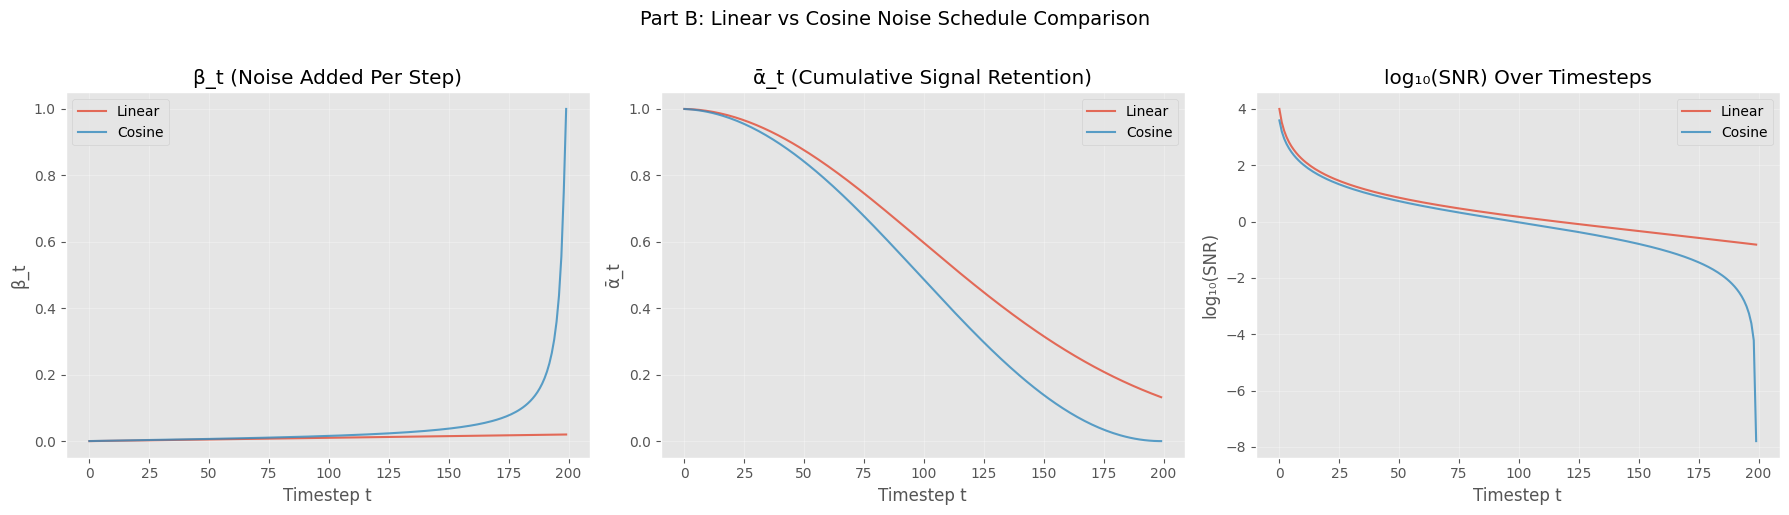


[Part B] Saved: noise_schedule_comparison.png


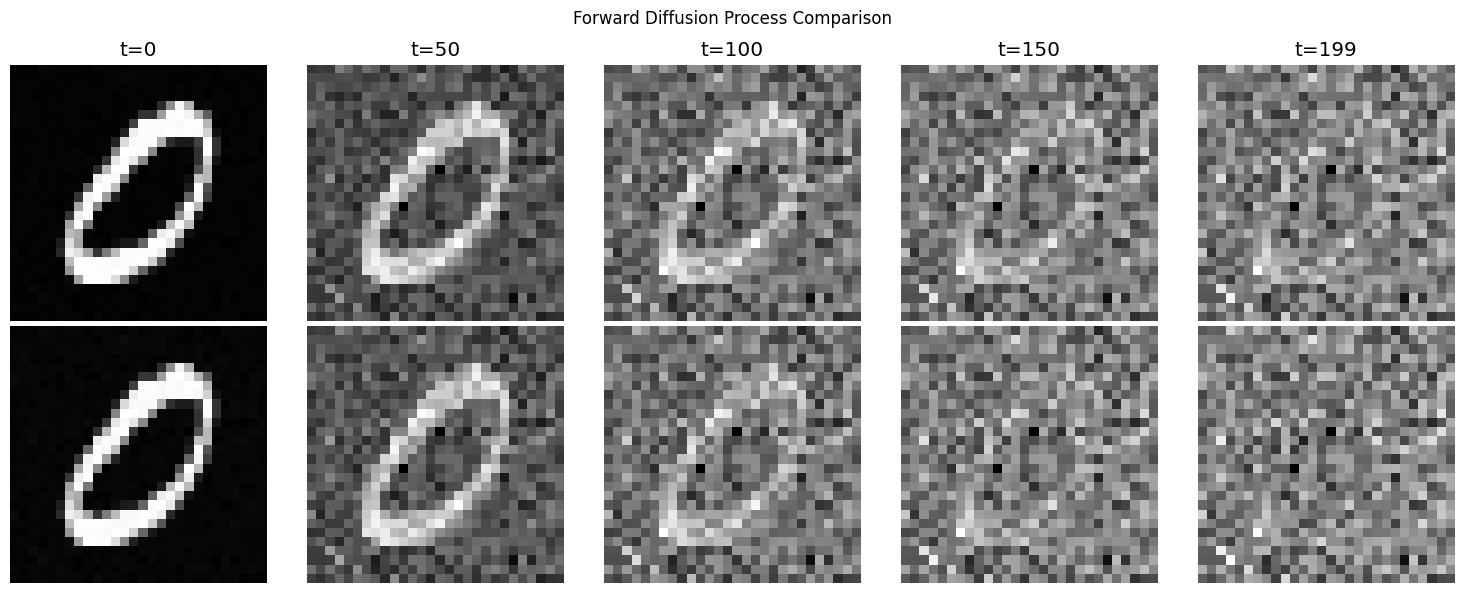


Training DDPM with cosine schedule for comparison...


Epoch 1/5: 100%|██████████| 39/39 [00:42<00:00,  1.09s/it, loss=0.1552]


  Epoch 1 average loss: 0.2721


Epoch 2/5: 100%|██████████| 39/39 [00:43<00:00,  1.11s/it, loss=0.1129]


  Epoch 2 average loss: 0.1267


...

Epoch 4/5: 100%|██████████| 39/39 [00:43<00:00,  1.11s/it, loss=0.0752]


  Epoch 4 average loss: 0.0835


Epoch 5/5: 100%|██████████| 39/39 [00:42<00:00,  1.09s/it, loss=0.0768]


  Epoch 5 average loss: 0.0759


Sampling: 100%|██████████| 200/200 [00:15<00:00, 13.32it/s]


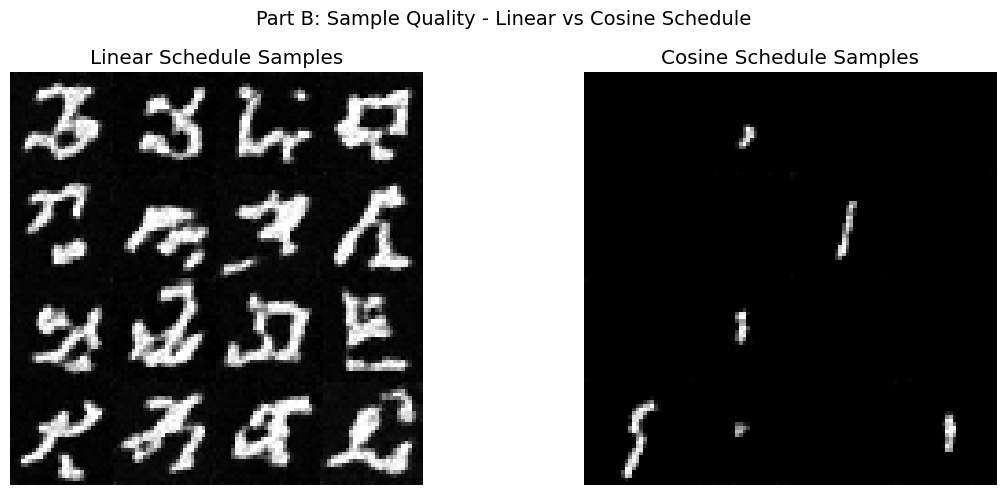

[Part B] Saved: schedule_samples_comparison.png

── Part B Analysis ──
Linear Schedule:
  - Betas increase uniformly; signal degrades faster at later timesteps
  - May waste model capacity on near-pure-noise timesteps
  - Final training loss: 0.0888
Cosine Schedule:
  - Smoother signal degradation; more information preserved at mid timesteps
  - Typically produces better sample quality (Nichol & Dhariwal, 2021)
  - Final training loss: 0.0759

PART C: Diffusion Model vs GAN Comparison
Generator parameters: 778,305
Discriminator parameters: 36,641


GAN Epoch 1/5: 100%|██████████| 39/39 [00:08<00:00,  4.83it/s, G=2.010, D=0.576]


  G_loss: 1.5745, D_loss: 0.7726


GAN Epoch 2/5: 100%|██████████| 39/39 [00:08<00:00,  4.58it/s, G=2.299, D=0.540]


  G_loss: 2.2236, D_loss: 0.5560


...

  G_loss: 2.0844, D_loss: 0.6148


GAN Epoch 4/5: 100%|██████████| 39/39 [00:08<00:00,  4.66it/s, G=1.643, D=0.706]


  G_loss: 1.8879, D_loss: 0.6763


GAN Epoch 5/5: 100%|██████████| 39/39 [00:08<00:00,  4.81it/s, G=1.634, D=0.778]
/tmp/ipykernel_18960/3114869729.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax4.boxplot([ddpm_means, gan_means], labels=["DDPM", "GAN"])


  G_loss: 1.6924, D_loss: 0.7769
GAN training time: 42.4s

Generating GAN samples...


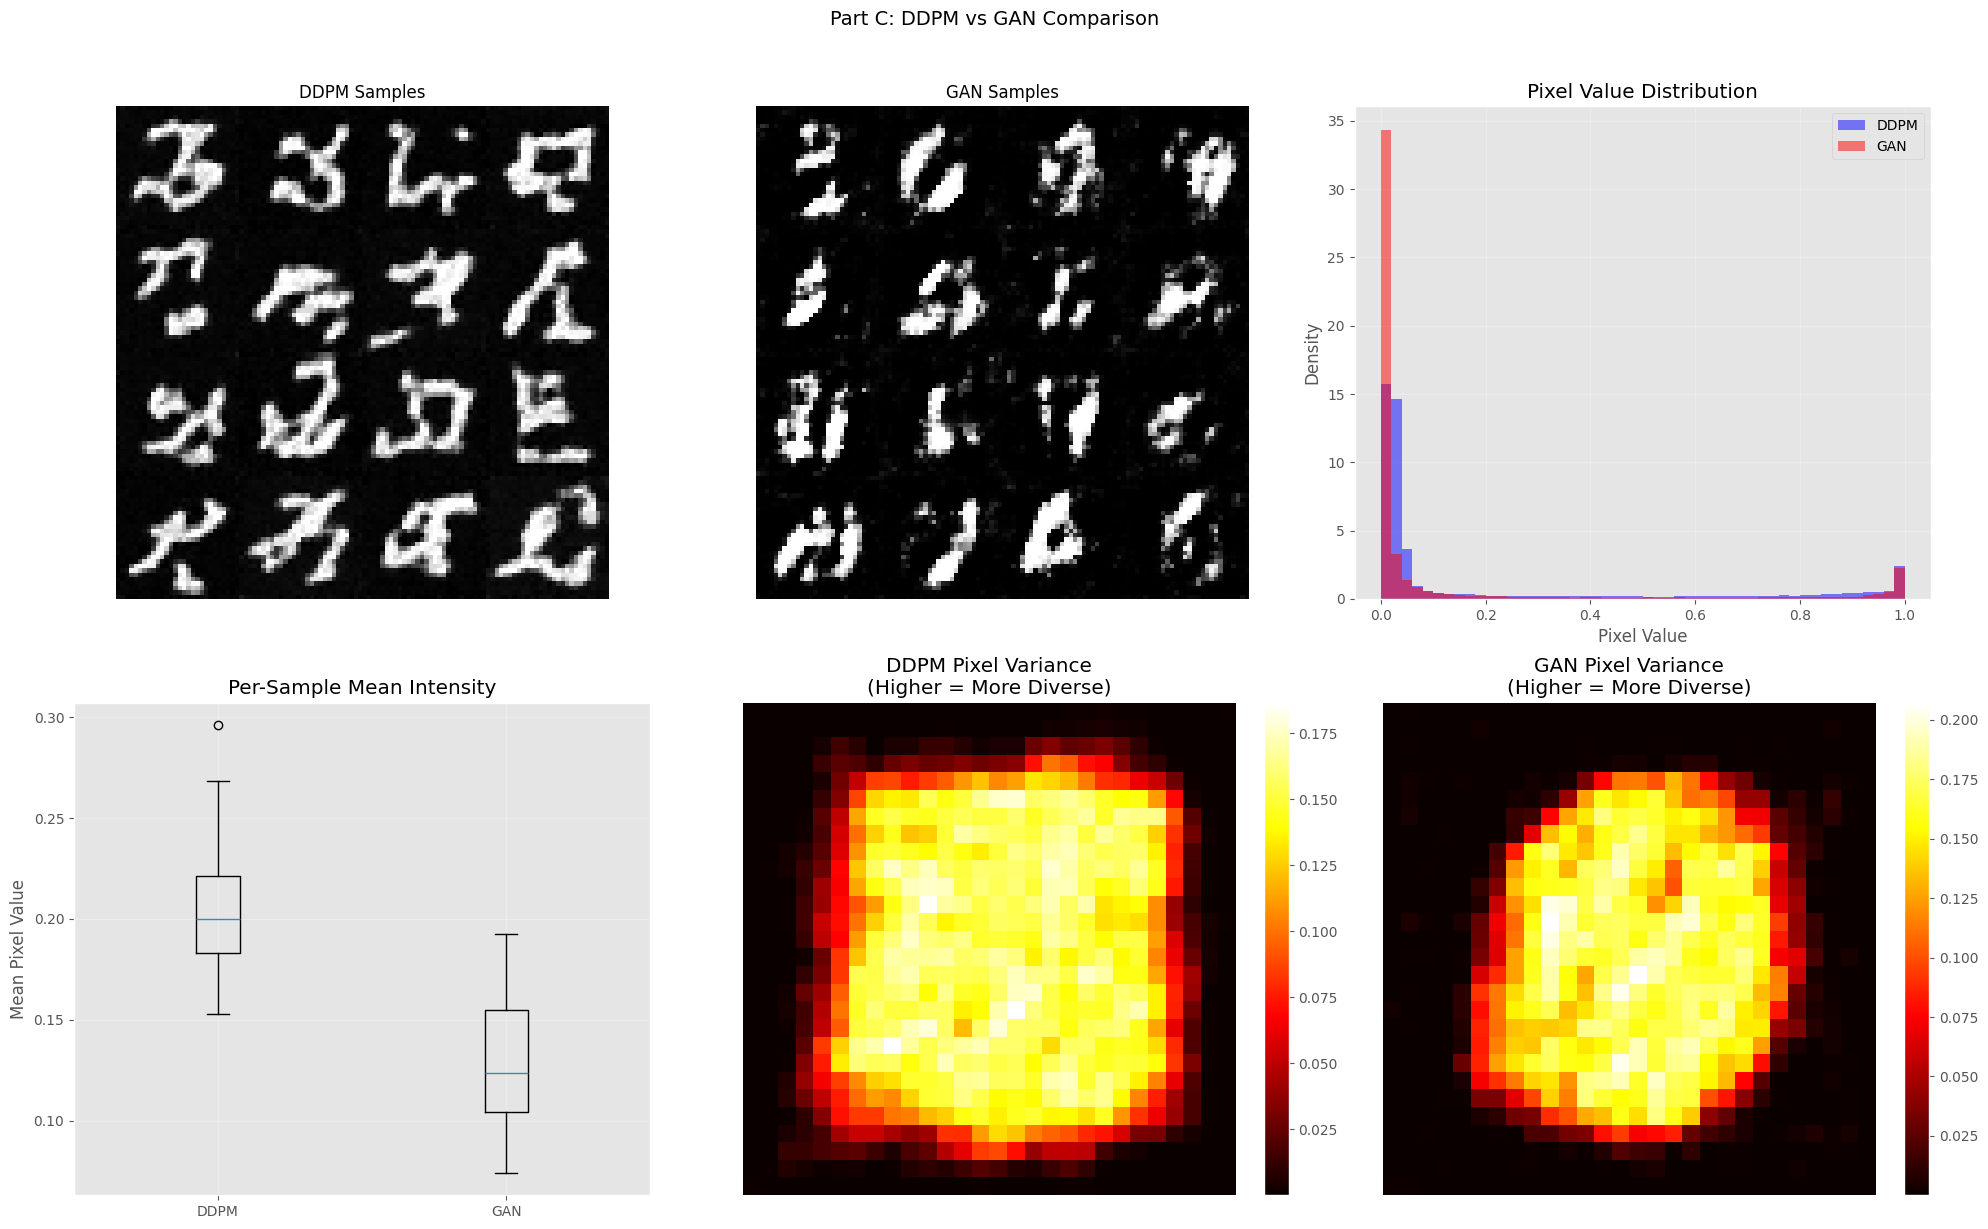


[Part C] Saved: ddpm_vs_gan_comparison.png


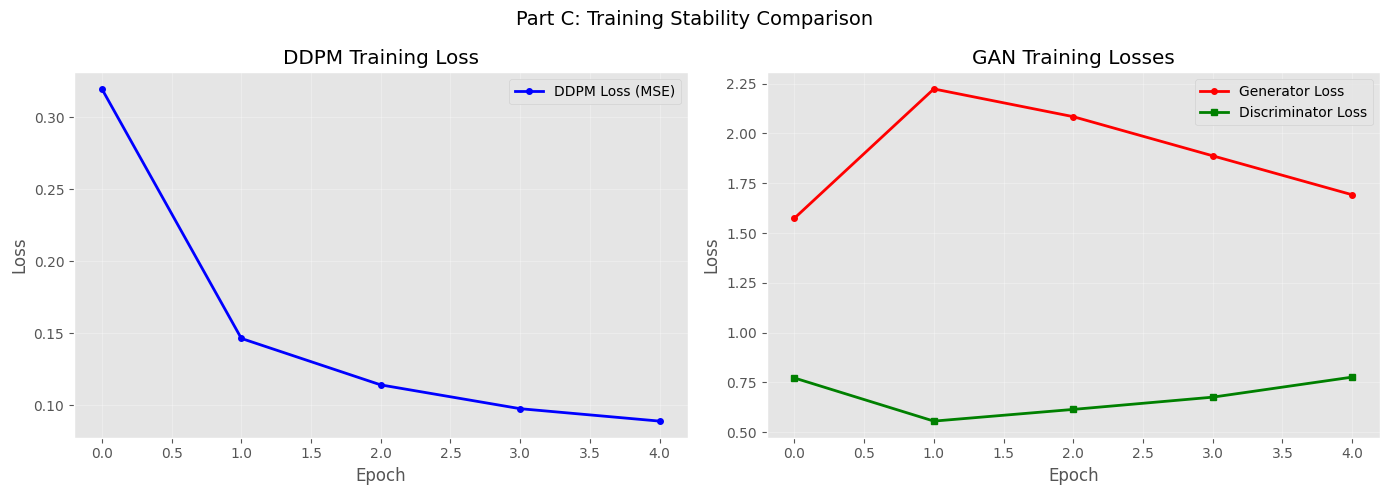

[Part C] Saved: training_stability_comparison.png

QUANTITATIVE COMPARISON: DDPM vs GAN
  Metric                 DDPM           GAN           
  ────────────────────   ────────────   ────────────  
  Mean pixel value       0.2025         0.1295        
  Pixel std dev          0.3260         0.2862        
  Inter-sample var       0.076058       0.059763      
  Edge sharpness         0.0886         0.0807        

── Analysis ──
  Diversity: DDPM shows higher diversity (0.076058 vs 0.059763)
  Sharpness: DDPM produces sharper edges

FINAL SUMMARY: DDPM vs GAN

┌─────────────────────┬──────────────────┬──────────────────┐
│ Criterion           │ DDPM             │ GAN              │
├─────────────────────┼──────────────────┼──────────────────┤
│ Training Objective  │ Simple MSE loss  │ Adversarial game │
│ Training Stability  │ Very stable      │ Can be unstable  │
│ Mode Collapse Risk  │ Very low         │ Moderate-high    │
│ Sample Diversity    │ High             │ Can be limited   

In [55]:
# ── Configuration (tuned for fast execution) ──
T = 200             # Diffusion timesteps (200 is sufficient for MNIST)
EPOCHS_DDPM = 5     # Training epochs for DDPM
EPOCHS_GAN = 5      # Training epochs for GAN
BATCH_SIZE = 256    # Larger batch = better GPU utilization
N_SAMPLES = 64      # Number of samples to generate for evaluation
SUBSET_SIZE = 10000 # Use a subset of MNIST for faster training

# ── Data Loading ──
# Normalize MNIST to [-1, 1] to match Tanh output range
transform = transforms.Compose([
   transforms.ToTensor(),
   transforms.Normalize([0.5], [0.5]),  # Map [0,1] -> [-1,1]
])
dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
# Use a random subset for faster training
subset_indices = torch.randperm(len(dataset))[:SUBSET_SIZE]
dataset = torch.utils.data.Subset(dataset, subset_indices)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=0, drop_last=True)

print("\n" + "=" * 70)
print("PART A: Denoising Diffusion Probabilistic Model (DDPM)")
print("=" * 70)

# ── A: Train DDPM with linear schedule ──
betas_linear = linear_noise_schedule(T)
diffusion_linear = DiffusionUtils(betas_linear, DEVICE)
model_ddpm = SimpleUNet(in_ch=1, base_ch=32).to(DEVICE)
param_count = sum(p.numel() for p in model_ddpm.parameters() if p.requires_grad)
print(f"DDPM U-Net parameters: {param_count:,}")

start_time = time.time()
ddpm_losses = train_ddpm(model_ddpm, diffusion_linear, dataloader, epochs=EPOCHS_DDPM)   
ddpm_train_time = time.time() - start_time
print(f"DDPM training time: {ddpm_train_time:.1f}s")

# Generate samples
print("\nGenerating DDPM samples...")
ddpm_samples = sample_ddpm(model_ddpm, diffusion_linear, n_samples=N_SAMPLES)

print("\n" + "=" * 70)
print("PART B: Noise Schedule Comparison")
print("=" * 70)

# ── B: Compare noise schedules ──
plot_noise_schedules(T)

# Visualize forward process with both schedules
betas_cosine = cosine_noise_schedule(T)
diffusion_cosine = DiffusionUtils(betas_cosine, DEVICE)
sample_img = next(iter(dataloader))[0][:1].to(DEVICE)  # Single sample image
visualize_forward_process(diffusion_linear, diffusion_cosine, sample_img)

# Train DDPM with cosine schedule for comparison
print("\nTraining DDPM with cosine schedule for comparison...")
model_ddpm_cosine = SimpleUNet(in_ch=1, base_ch=32).to(DEVICE)
ddpm_cosine_losses = train_ddpm(model_ddpm_cosine, diffusion_cosine, dataloader,
                                 epochs=EPOCHS_DDPM)

# Generate samples with cosine schedule
ddpm_cosine_samples = sample_ddpm(model_ddpm_cosine, diffusion_cosine, n_samples=N_SAMPLES)

# ── Compare samples from both schedules ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.imshow(make_grid(ddpm_samples[:16], nrow=4), cmap="gray")
ax1.set_title("Linear Schedule Samples")
ax1.axis("off")
ax2.imshow(make_grid(ddpm_cosine_samples[:16], nrow=4), cmap="gray")
ax2.set_title("Cosine Schedule Samples")
ax2.axis("off")
plt.suptitle("Part B: Sample Quality - Linear vs Cosine Schedule", fontsize=14)
plt.tight_layout()
plt.savefig("schedule_samples_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("[Part B] Saved: schedule_samples_comparison.png")

# Print schedule comparison analysis
print("\n── Part B Analysis ──")
print("Linear Schedule:")
print("  - Betas increase uniformly; signal degrades faster at later timesteps")
print("  - May waste model capacity on near-pure-noise timesteps")
print(f"  - Final training loss: {ddpm_losses[-1]:.4f}")
print("Cosine Schedule:")
print("  - Smoother signal degradation; more information preserved at mid timesteps")
print("  - Typically produces better sample quality (Nichol & Dhariwal, 2021)")
print(f"  - Final training loss: {ddpm_cosine_losses[-1]:.4f}")

print("\n" + "=" * 70)
print("PART C: Diffusion Model vs GAN Comparison")
print("=" * 70)

# ── C: Train GAN ──
generator = Generator(latent_dim=100, base_ch=32).to(DEVICE)
discriminator = Discriminator(base_ch=32).to(DEVICE)
g_params = sum(p.numel() for p in generator.parameters() if p.requires_grad)
d_params = sum(p.numel() for p in discriminator.parameters() if p.requires_grad)
print(f"Generator parameters: {g_params:,}")
print(f"Discriminator parameters: {d_params:,}")

start_time = time.time()
g_losses, d_losses = train_gan(generator, discriminator, dataloader,
                              epochs=EPOCHS_GAN, latent_dim=100)
gan_train_time = time.time() - start_time
print(f"GAN training time: {gan_train_time:.1f}s")

# Generate GAN samples
print("\nGenerating GAN samples...")
generator.eval()
with torch.no_grad():
   z = torch.randn(N_SAMPLES, 100, device=DEVICE)
   gan_samples = generator(z)
   gan_samples = (gan_samples + 1) / 2  # Rescale to [0, 1]

# ── C: Full Comparison ──
compare_outputs(ddpm_samples, gan_samples)
plot_training_comparison(ddpm_losses, g_losses, d_losses)
print_quantitative_comparison(ddpm_samples, gan_samples)

# ── Final Summary ──
print("\n" + "=" * 70)
print("FINAL SUMMARY: DDPM vs GAN")
print("=" * 70)
print(f"""
┌─────────────────────┬──────────────────┬──────────────────┐
│ Criterion           │ DDPM             │ GAN              │
├─────────────────────┼──────────────────┼──────────────────┤
│ Training Objective  │ Simple MSE loss  │ Adversarial game │
│ Training Stability  │ Very stable      │ Can be unstable  │
│ Mode Collapse Risk  │ Very low         │ Moderate-high    │
│ Sample Diversity    │ High             │ Can be limited   │
│ Sample Quality      │ High (slow)      │ Good (fast)      │
│ Sampling Speed      │ Slow ({T} steps) │ Fast (1 pass)    │
│ Training Time       │ {ddpm_train_time:.0f}s             │ {gan_train_time:.0f}s             │
│ Theory              │ Well-grounded    │ Game-theoretic   │
└─────────────────────┴──────────────────┴──────────────────┘
""")